# $MINKOWSKI$

## $M = 2 H_I$

--- Integrando Minkowski (m=2.0, Adiabacidad=1.0e-05) ---
Modo  | k/k_final  | t_inicio     | nk Final     | Precisión(Wr)  | Estado
---------------------------------------------------------------------------
1     | 0.01       | 42.50        | 2.35e-04     | 1.3e-09        | PRECISO
2     | 0.01       | 42.73        | 2.33e-04     | 1.3e-09        | PRECISO
3     | 0.02       | 42.97        | 2.34e-04     | 1.3e-09        | PRECISO
4     | 0.02       | 43.21        | 2.36e-04     | 1.3e-09        | PRECISO
5     | 0.03       | 43.45        | 2.39e-04     | 1.3e-09        | PRECISO
6     | 0.03       | 43.69        | 2.40e-04     | 1.3e-09        | PRECISO
7     | 0.04       | 43.92        | 2.37e-04     | 1.3e-09        | PRECISO
8     | 0.05       | 44.16        | 2.31e-04     | 1.3e-09        | PRECISO
9     | 0.07       | 44.40        | 2.22e-04     | 1.3e-09        | PRECISO
10    | 0.09       | 44.64        | 2.11e-04     | 1.3e-09        | PRECISO
11    | 0.11       | 44.88     

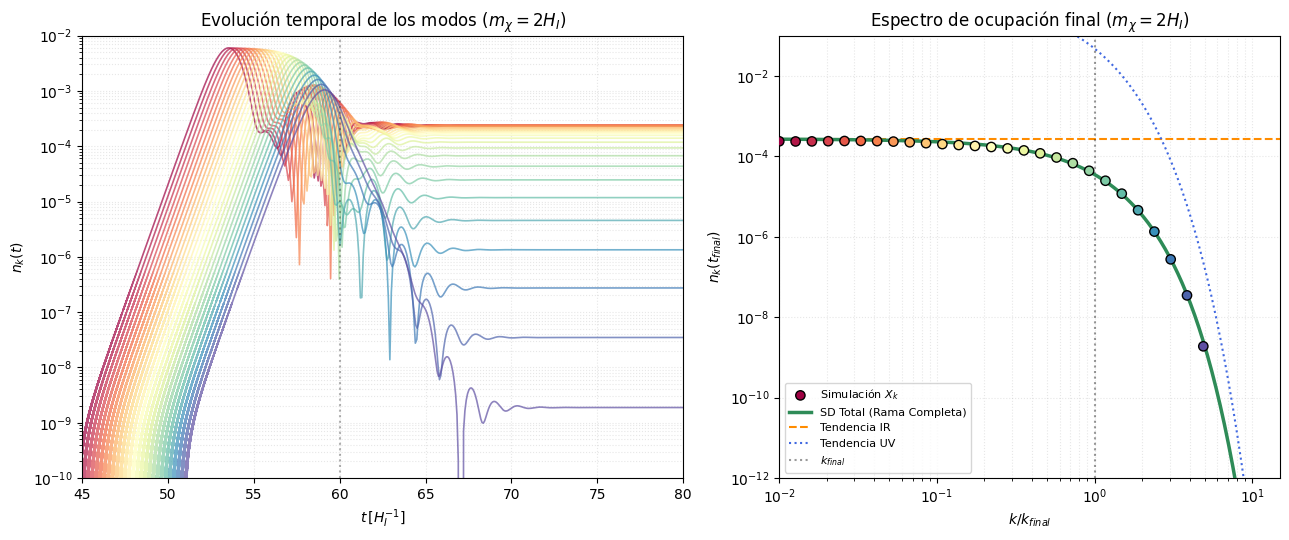

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, brentq
from scipy.integrate import solve_ivp
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CONFIGURACIÓN (HI=1)
# ============================================================
M_planck, H_inflacion = 1.0, 1.0 #normalización de rigor
a_final_infl = 1.0
t_final_infl = 60.0    #centro de la transición suave
t_final_sim = 120.0    #tiempo para alcanzar el régimen asintótico
m_chi = 2.0 * H_inflacion 


#ajustes de precisión para no perder la fase en los modos UV
objetivo_adiabatico = 1e-5
t_suelo_ir = 35.0      #para que los modos IR no empiecen en el "Big Bang"
tol_rel, tol_abs = 1e-12, 1e-14

# ============================================================
# 2. DINÁMICA DE FONDO (Transición a Minkowski)
# ============================================================
def a_fnd(t): 
    return 2 * a_final_infl * np.exp(H_inflacion * (t - t_final_infl)) / (1 + np.exp(H_inflacion * (t - t_final_infl)))

def H_fnd(t): 
    return H_inflacion / (1 + np.exp(H_inflacion * (t - t_final_infl)))
k_final_infl = a_final_infl * H_fnd(t_final_infl)

def H_punto_fnd(t):
    exp_term = np.exp(H_inflacion * (t - t_final_infl))
    return -H_inflacion**2 * exp_term / (1 + exp_term)**2

def omega2_compleja(t_c, k_v):
    #fondo extendido al plano complejo para el cálculo de polos
    a_c = 2*a_final_infl*cmath.exp(H_inflacion*(t_c-t_final_infl)) / (1 + cmath.exp(H_inflacion*(t_c-t_final_infl)))
    H_c = H_inflacion/(1 + cmath.exp(H_inflacion*(t_c-t_final_infl)))
    Hd_c = -H_inflacion**2 * cmath.exp(H_inflacion*(t_c-t_final_infl)) / (1+cmath.exp(H_inflacion*(t_c-t_final_infl)))**2
    return k_v**2/a_c**2 + m_chi**2 - 2.25*H_c**2 - 1.5*Hd_c

# ============================================================
# 3. INTEGRACIÓN NUMÉRICA DE MODOS (Guardado Dinámico)
# ============================================================
def omega2_numerico(t, k):
    return k**2/a_fnd(t)**2 + m_chi**2 - 2.25*H_fnd(t)**2 - 1.5*H_punto_fnd(t)

def calc_adiabaticidad(t, k):
    w2 = np.maximum(omega2_numerico(t, k), 1e-30)
    w = np.sqrt(w2)
    dt = 1e-5
    w_der = (np.sqrt(np.maximum(omega2_numerico(t+dt, k), 1e-30)) - 
             np.sqrt(np.maximum(omega2_numerico(t-dt, k), 1e-30))) / (2.0*dt)
    return np.abs(w_der / w2)

def Omega_integral(tp, k):
    tR, tI = tp.real, tp.imag
    #subdivisión para integrar la fase compleja
    ys = np.linspace(0.0, abs(tI), 6000)
    ts = tR - 1j*ys
    ws = np.array([cmath.sqrt(omega2_compleja(t, k)) for t in ts])
    #integral numérica usando la regla del trapecio (más precisa que sum)
    Phase = -1j * np.trapezoid(ws, x=ys) 
    return Phase

#malla de momentos k (IR: 10^-2 a UV: 10^1)
k_lista = np.logspace(-2, 1, 30) * k_final_infl
#k_lista = k_lista[[15]] LO USABA PARA COMPROBACIONES
nk_final_lista, lista_evolucion_nk, lista_tiempos, wr_err_lista = [], [], [], []

print(f"--- Integrando Minkowski (m={m_chi}, Adiabacidad={objetivo_adiabatico:.1e}) ---")
print(f"{'Modo':<5} | {'k/k_final':<10} | {'t_inicio':<12} | {'nk Final':<12} | {'Precisión(Wr)':<14} | {'Estado'}")
print("-" * 75)

for i, k in enumerate(k_lista):
    try:
        t_ini = brentq(lambda t: calc_adiabaticidad(t, k) - objetivo_adiabatico, 5.0, t_final_infl - 1.0)
    except:
        t_ini = t_suelo_ir
    
    t_inicio_modo = np.clip(t_ini, t_suelo_ir, t_final_infl - 2.0)
    
    #c.i. WKB (orden 1)
    w0 = np.sqrt(np.maximum(omega2_numerico(t_inicio_modo, k), 1e-30))
    X0 = 1.0 / np.sqrt(2.0 * w0)
    dt_eps = 1e-6
    w_der0 = (np.sqrt(np.maximum(omega2_numerico(t_inicio_modo+dt_eps, k), 1e-30)) - 
              np.sqrt(np.maximum(omega2_numerico(t_inicio_modo-dt_eps, k), 1e-30))) / (2.0*dt_eps)
    X_der0 = (-w_der0 / (4.0 * w0) - 1j * w0) * X0
    
    sol = solve_ivp(lambda t, y: [y[2], y[3], -omega2_numerico(t, k)*y[0], -omega2_numerico(t, k)*y[1]], 
                    (t_inicio_modo, t_final_sim), [X0.real, X0.imag, X_der0.real, X_der0.imag], 
                    method='DOP853', rtol=tol_rel, atol=tol_abs)
    
    #cálculo del wronskiano (precisión mínima del integrador)
    X_n = sol.y[0] + 1j*sol.y[1]
    Xd_n = sol.y[2] + 1j*sol.y[3]
    wr_err = np.max(np.abs(X_n * np.conj(Xd_n) - np.conj(X_n) * Xd_n - 1j))
    
    #cálculo de nk asintótico
    w_eval = np.sqrt(np.maximum(omega2_numerico(sol.t, k), 1e-30))
    nk_evol = (np.abs(Xd_n)**2 + w_eval**2 * np.abs(X_n)**2) / (2.0 * w_eval) - 0.5
    nk_final_val = nk_evol[-1].real
    
    #--- lógica de discriminación ---
    if nk_final_val < wr_err:
        #si es menor que el error, lo marcamos como NaN (no saldrá en la gráfica)
        display_nk = "Bajo Ruido"
        nk_to_save = np.nan 
        status = "IMPRECISO (DESCARTADO)" #valor inferior a la condición wronskiana
        #Imprimimos antes de romper para saber cuál falló
        print(f"{i+1:<5d} | {k/k_final_infl:<10.2f} | {t_inicio_modo:<12.2f} | {display_nk:<12} | {wr_err:<14.1e} | {status}")
        break #termino el bucle for (el resto seguiran siedno imprecisos también
    else:
        display_nk = f"{nk_final_val:.2e}"
        nk_to_save = nk_final_val
        status = "PRECISO" #valor superior a la condición wronskiana
        
    #guardado de datos
    nk_final_lista.append(nk_to_save)
    wr_err_lista.append(wr_err)
    lista_evolucion_nk.append(nk_evol.real)
    lista_tiempos.append(sol.t)
    
    #print informativo 
    print(f"{i+1:<5d} | {k/k_final_infl:<10.2f} | {t_inicio_modo:<12.2f} | {display_nk:<12} | {wr_err:<14.1e} | {status}")
    
    #guardado dinámico en disco
    np.savez(f"datos_minkowski_m{m_chi}.npz", 
             k_ratio=k_lista[:i+1]/k_final_infl, 
             nk_final=nk_final_lista, 
             wr_errors=wr_err_lista,
             times=np.array(lista_tiempos, dtype=object), 
             nk_evolutions=np.array(lista_evolucion_nk, dtype=object))

# ============================================================
# 4. VALIDACIÓN ANALÍTICA (Corregida con barrido bi-direccional)
# ============================================================
k_sd_eje = np.logspace(-2, 1.2, 120) * k_final_infl
results_sd_dict = {}

#1. punto de anclaje (en el medio de la malla k)
mid_idx = len(k_sd_eje) // 2
z_seed = np.array([t_final_infl, 1.53]) #semilla estable cerca de la transición

#2. barrido hacia el IR (descendente)
temp_seed = z_seed.copy()
for i in range(mid_idx, -1, -1):
    kv = k_sd_eje[i]
    sol_p = root(lambda z: [omega2_compleja(z[0]+1j*z[1], kv).real, 
                            omega2_compleja(z[0]+1j*z[1], kv).imag], temp_seed)
    if sol_p.success:
        temp_seed = sol_p.x
        Ph = Omega_integral(sol_p.x[0] + 1j*sol_p.x[1], kv)
        results_sd_dict[i] = (np.pi**2 / 9.0) * np.exp(4.0 * Ph.imag)

#3. barrido hacia el UV (ascendente)
temp_seed = z_seed.copy()
for i in range(mid_idx + 1, len(k_sd_eje)):
    kv = k_sd_eje[i]
    sol_p = root(lambda z: [omega2_compleja(z[0]+1j*z[1], kv).real, 
                            omega2_compleja(z[0]+1j*z[1], kv).imag], temp_seed)
    if sol_p.success:
        temp_seed = sol_p.x
        Ph = Omega_integral(sol_p.x[0] + 1j*sol_p.x[1], kv)
        results_sd_dict[i] = (np.pi**2 / 9.0) * np.exp(4.0 * Ph.imag)

#4. reconstruir array final
nk_sd_curva = [results_sd_dict.get(i, np.nan) for i in range(len(k_sd_eje/(k_final_infl)))]

#tendencias asintóticas dinámicas
nu_param = np.sqrt(m_chi**2 - 2.25)
nk_ir_asint = (np.pi**2 / 9.0) * np.exp(-2.0 * np.pi * nu_param)
nk_uv_asint = (np.pi**2 / 9.0) * np.exp(-2.0 * np.pi * k_sd_eje)
# ============================================================
# 5. GRÁFICA DE RESULTADOS (Dos Paneles)
# ============================================================
colores_spec = cm.Spectral(np.linspace(0, 1, len(nk_final_lista)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios':[1.2, 1]})

#panel izquierdo: evolución temporal
for i in range(len(nk_final_lista)):
    ax1.plot(lista_tiempos[i], np.maximum(lista_evolucion_nk[i], 1e-40), color=colores_spec[i], lw=1.2, alpha=0.7)
ax1.set_yscale('log')
ax1.set_xlim(45, t_final_sim-40)
ax1.set_ylim(1e-10, 1e-2)
ax1.axvline(t_final_infl, color='black', ls=':', alpha=0.3, label='Transición')
ax1.set_xlabel(r'$t\,[H_I^{-1}]$')
ax1.set_ylabel(r'$n_k(t)$')
ax1.set_title(r'Evolución temporal de los modos ($m_\chi = 2 H_I$)')
ax1.grid(True, which='both', ls=':', alpha=0.3)

#panel derecho: espectro y validación teórica
ax2.scatter(k_lista[:len(nk_final_lista)]/k_final_infl, np.maximum(nk_final_lista, 1e-40), c=colores_spec, 
            edgecolor='black', s=45, zorder=5, label=r'Simulación $X_k$')

#curvas de validación
ax2.loglog(k_sd_eje/(k_final_infl), nk_sd_curva, color='seagreen', ls='-', lw=2.5, label='SD Total (Rama Completa)', zorder=4)
ax2.axhline(nk_ir_asint, color='darkorange', ls='--', lw=1.5, label='Tendencia IR ')
ax2.loglog(k_sd_eje/(k_final_infl), nk_uv_asint, color='royalblue', ls=':', lw=1.5, label='Tendencia UV ')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(1e-12, 1e-1)
ax2.set_xlim(1e-2, 15)
ax2.axvline(1.0, color='black', ls=':', alpha=0.4, label='$k_{final}$')
ax2.set_xlabel(r'$k/k_{final}$')
ax2.set_ylabel(r'$n_k(t_{final})$')
ax2.set_title(r'Espectro de ocupación final ($m_\chi = 2 H_I$)')
ax2.legend(fontsize=8, loc='lower left', frameon=True)
ax2.grid(True, which='both', ls=':', alpha=0.3)
plt.tight_layout()

# 1. Calcular las coordenadas en pulgadas de cada panel con un 5% de margen extra
bbox_ax1 = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)
bbox_ax2 = ax2.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# 2. Guardar cada panel de forma independiente usando sus coordenadas
plt.savefig(f"Fig1_Evolucion_Temporal_m{m_chi}.pdf", bbox_inches=bbox_ax1)
plt.savefig(f"Fig2_Espectro_Validacion_m{m_chi}.pdf", bbox_inches=bbox_ax2)

print(f"Archivos PDF guardados para m={m_chi}")
plt.show()

plt.show()

Calculando rama de Steepest Descent (Paseo del Polo)...


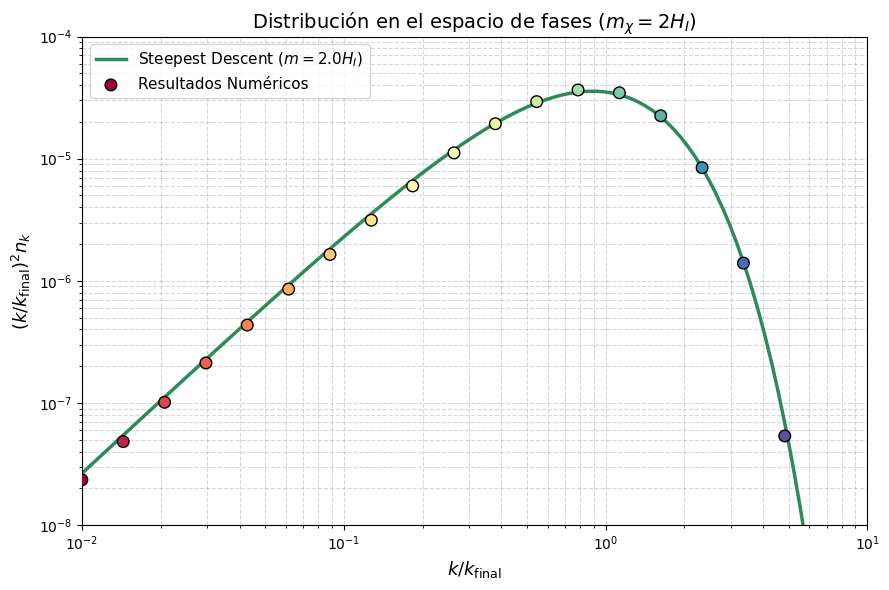


--- RESULTADO DE LA PRODUCCIÓN TOTAL ---
n_chi físico          = 3.540251e-07


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CARGA DE DATOS
# ============================================================
#h_I = 1 normalización de las simulaciones
H_inflacion = 1.0
a_final_infl = 1.0
t_final_infl = 60.0
m_chi = 2.0 * H_inflacion 

k_final_infl = a_final_infl * H_fnd(t_final_infl)

#archivo generado por el motor de integración
archivo_npz = f"datos_minkowski_m{m_chi}.npz"

if not os.path.exists(archivo_npz):
    print(f"Ojo: No veo el archivo {archivo_npz}. Hay que correr la simulación primero.")
    exit()

#extraemos los resultados numéricos
datos = np.load(archivo_npz, allow_pickle=True)
k_ratio_num = datos['k_ratio']
nk_num = datos['nk_final']

# ============================================================
# 2. FUNCIONES ANALÍTICAS (SD Y FONDO COMPLEJO)
# ============================================================
def omega2_compleja(t_c, k_v):
    #definición del fondo de minkowski para el plano complejo
    a_c = 2*a_final_infl*cmath.exp(H_inflacion*(t_c-t_final_infl)) / (1 + cmath.exp(H_inflacion*(t_c-t_final_infl)))
    H_c = H_inflacion/(1 + cmath.exp(H_inflacion*(t_c-t_final_infl)))
    Hd_c = -H_inflacion**2 * cmath.exp(H_inflacion*(t_c-t_final_infl)) / (1+cmath.exp(H_inflacion*(t_c-t_final_infl)))**2
    return k_v**2/a_c**2 + m_chi**2 - 2.25*H_c**2 - 1.5*Hd_c

def integral_Omega(tp, k):
    tR, tI = tp.real, tp.imag
    ys = np.linspace(0.0, abs(tI), 8000)
    ws = np.array([cmath.sqrt(omega2_compleja(tR - 1j*y, k)) for y in ys])
    
    # ========================================================
    # CONTROL DE CONTINUIDAD DE RAMA (Evita el colapso por signo)
    # ========================================================
    for i in range(1, len(ws)):
        if np.real(ws[i] * np.conj(ws[i-1])) < 0:
            ws[i] = -ws[i]
            
    #integral numérica para la fase (regla del trapecio)
    return -1j * np.trapezoid(ws, x=ys)

# ============================================================
# 3. CÁLCULO DE LA CURVA VERDE (Steepest Descent Dinámico)
# ============================================================
 #generamos una malla fina para que la línea se vea suave
k_sd_eje = np.logspace(-2, 1.2, 120) * k_final_infl
results_sd = {}
#punto de inicio para el paseo del polo (en el centro para estabilidad)
idx_ref = len(k_sd_eje) // 2
semilla = np.array([t_final_infl, 1.53]) 
    
print("Calculando rama de Steepest Descent (Paseo del Polo)...")
#barrido ir (hacia atrás)
z_temp = semilla.copy()
for i in range(idx_ref, -1, -1):
    kv = k_sd_eje[i]
    sol = root(lambda z: [omega2_compleja(z[0]+1j*z[1], kv).real, 
                          omega2_compleja(z[0]+1j*z[1], kv).imag], z_temp)
    if sol.success:
        z_temp = sol.x
        fase = integral_Omega(sol.x[0] + 1j*sol.x[1], kv)
        results_sd[i] = (np.pi**2 / 9.0) * np.exp(4.0 * fase.imag)
#barrido uv (hacia adelante)
z_temp = root(lambda z: [omega2_compleja(z[0]+1j*z[1], k_sd_eje[idx_ref]).real, 
                          omega2_compleja(z[0]+1j*z[1], k_sd_eje[idx_ref]).imag], semilla).x
for i in range(idx_ref + 1, len(k_sd_eje)):
    kv = k_sd_eje[i]
    sol = root(lambda z: [omega2_compleja(z[0]+1j*z[1], kv).real, 
                          omega2_compleja(z[0]+1j*z[1], kv).imag], z_temp)
    if sol.success:
        z_temp = sol.x
        fase = integral_Omega(sol.x[0] + 1j*sol.x[1], kv)
        results_sd[i] = (np.pi**2 / 9.0) * np.exp(4.0 * fase.imag)
nk_sd_curva = np.array([results_sd.get(i, np.nan) for i in range(len(k_sd_eje))]) 

# ============================================================
# 4. REPRESENTACIÓN: PHASE SPACE DISTRIBUTION
# ============================================================
#mantenemos el degradado spectral del otro código
#generamos los colores basados en la cantidad de datos cargados
n_modos = len(nk_num)
colores_spec = cm.Spectral(np.linspace(0, 1, n_modos))

#transformación a espacio de fases (k/k_f)^2 * n_k
y_num_fases = (k_ratio_num**2) * nk_num
y_teoria_fases = ((k_sd_eje/k_final_infl)**2) * nk_sd_curva

plt.figure(figsize=(9, 6))

#línea sd verde 
plt.loglog(k_sd_eje/k_final_infl, y_teoria_fases, color='seagreen', lw=2.5, 
           label=f"Steepest Descent ($m={m_chi/H_inflacion:.1f} H_I$)")


#usamos c=colores_spec para mantener el formato
plt.scatter(k_ratio_num, y_num_fases, c=colores_spec, edgecolor='black', 
            s=70, label="Resultados Numéricos", zorder=5)

#ajustes estéticos
plt.xlabel(r"$k/k_{\rm final}$", fontsize=13)
plt.ylabel(r"$(k/k_{\rm final})^2 n_k$", fontsize=13)
plt.title(r'Distribución en el espacio de fases ($m_\chi = 2 H_I$)', fontsize=14)

#límites 
plt.xlim(0.01, 10)
plt.ylim(1e-8, 1e-4)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, frameon=True)
plt.tight_layout()

#guardamos la gráfica 
plt.savefig(f"Phase_Space_Minkowski_m{m_chi}.png", dpi=300)
plt.show()
# ============================================================
# 5. VALOR DE LA INTEGRAL EN EL ESPACIO DE FASES (CORREGIDO)
# ============================================================
# Calculamos primero la densidad física real n_chi 
# Usamos el eje físico k_sd_eje y su diferencial dk para no perder el jacobiano
n_chi_real = (1.0 / (2 * np.pi**2)) * np.trapezoid(k_sd_eje**2 * nk_sd_curva, x=k_sd_eje)

# Ahora calculamos el valor normalizado respecto a k_final^3
n_normalizada_fases = n_chi_real / (k_final_infl**3)

print(f"\n--- RESULTADO DE LA PRODUCCIÓN TOTAL ---")
print(f"n_chi físico          = {n_chi_real:.6e}")

## $M = 3 H_I \,(Código \,Idéntico)$

--- Integrando Minkowski (m=3.0, Adiabacidad=8.0e-05) ---
Modo  | k/k_final  | t_inicio     | nk Final     | Precisión(Wr)  | Estado
---------------------------------------------------------------------------
1     | 0.01       | 44.58        | 7.60e-08     | 1.5e-10        | PRECISO
2     | 0.01       | 44.81        | 7.57e-08     | 1.5e-10        | PRECISO
3     | 0.02       | 45.05        | 7.53e-08     | 1.5e-10        | PRECISO
4     | 0.02       | 45.29        | 7.47e-08     | 1.5e-10        | PRECISO
5     | 0.03       | 45.53        | 7.39e-08     | 1.5e-10        | PRECISO
6     | 0.03       | 45.77        | 7.29e-08     | 1.5e-10        | PRECISO
7     | 0.04       | 46.00        | 7.18e-08     | 1.5e-10        | PRECISO
8     | 0.05       | 46.24        | 7.05e-08     | 1.5e-10        | PRECISO
9     | 0.07       | 46.48        | 6.87e-08     | 1.5e-10        | PRECISO
10    | 0.09       | 46.72        | 6.65e-08     | 1.5e-10        | PRECISO
11    | 0.11       | 46.96     

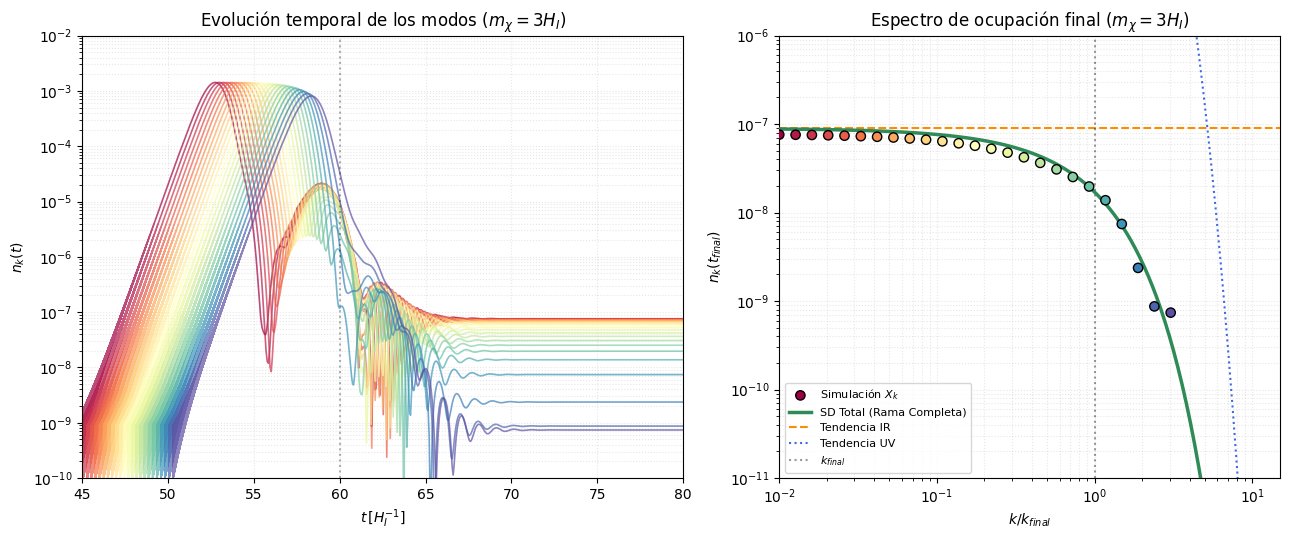

Archivos PDF guardados para m=3.0


<Figure size 640x480 with 0 Axes>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, brentq
from scipy.integrate import solve_ivp
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CONFIGURACIÓN (HI=1)
# ============================================================
M_planck, H_inflacion = 1.0, 1.0 #normalización de rigor
a_final_infl = 1.0
t_final_infl = 60.0    #centro de la transición suave
t_final_sim = 120.0    #tiempo para alcanzar el régimen asintótico
m_chi = 3.0 * H_inflacion 
k_final_infl = a_final_infl * H_fnd(t_final_infl)

#ajustes de precisión para no perder la fase en los modos UV
objetivo_adiabatico = 8e-5 #balance entre precisión y conseguir modos UV
t_suelo_ir = 35.0      #para que los modos IR no empiecen en el "Big Bang"
tol_rel, tol_abs = 1e-12, 1e-14

# ============================================================
# 2. DINÁMICA DE FONDO (Transición a Minkowski)
# ============================================================
def a_fnd(t): 
    return 2 * a_final_infl * np.exp(H_inflacion * (t - t_final_infl)) / (1 + np.exp(H_inflacion * (t - t_final_infl)))

def H_fnd(t): 
    return H_inflacion / (1 + np.exp(H_inflacion * (t - t_final_infl)))

def H_punto_fnd(t):
    exp_term = np.exp(H_inflacion * (t - t_final_infl))
    return -H_inflacion**2 * exp_term / (1 + exp_term)**2

def omega2_compleja(t_c, k_v):
    #fondo extendido al plano complejo para el cálculo de polos
    a_c = 2*a_final_infl*cmath.exp(H_inflacion*(t_c-t_final_infl)) / (1 + cmath.exp(H_inflacion*(t_c-t_final_infl)))
    H_c = H_inflacion/(1 + cmath.exp(H_inflacion*(t_c-t_final_infl)))
    Hd_c = -H_inflacion**2 * cmath.exp(H_inflacion*(t_c-t_final_infl)) / (1+cmath.exp(H_inflacion*(t_c-t_final_infl)))**2
    return k_v**2/a_c**2 + m_chi**2 - 2.25*H_c**2 - 1.5*Hd_c

# ============================================================
# 3. INTEGRACIÓN NUMÉRICA DE MODOS (Guardado Dinámico)
# ============================================================
def omega2_numerico(t, k):
    return k**2/a_fnd(t)**2 + m_chi**2 - 2.25*H_fnd(t)**2 - 1.5*H_punto_fnd(t)

def calc_adiabaticidad(t, k):
    w2 = np.maximum(omega2_numerico(t, k), 1e-30)
    w = np.sqrt(w2)
    dt = 1e-5
    w_der = (np.sqrt(np.maximum(omega2_numerico(t+dt, k), 1e-30)) - 
             np.sqrt(np.maximum(omega2_numerico(t-dt, k), 1e-30))) / (2.0*dt)
    return np.abs(w_der / w2)

def Omega_integral(tp, k):
    tR, tI = tp.real, tp.imag
    #subdivisión para integrar la fase compleja
    ys = np.linspace(0.0, abs(tI), 6000)
    ts = tR - 1j*ys
    ws = np.array([cmath.sqrt(omega2_compleja(t, k)) for t in ts])
    #integral numérica usando la regla del trapecio (más precisa que sum)
    Phase = -1j * np.trapezoid(ws, x=ys) 
    return Phase

#malla de momentos k (IR: 10^-2 a UV: 10^1)
k_lista = np.logspace(-2, 1, 30) * k_final_infl
#k_lista = k_lista[[19]] (Comprobaciones)
nk_final_lista, lista_evolucion_nk, lista_tiempos, wr_err_lista = [], [], [], []

print(f"--- Integrando Minkowski (m={m_chi}, Adiabacidad={objetivo_adiabatico:.1e}) ---")
print(f"{'Modo':<5} | {'k/k_final':<10} | {'t_inicio':<12} | {'nk Final':<12} | {'Precisión(Wr)':<14} | {'Estado'}")
print("-" * 75)

for i, k in enumerate(k_lista):
    try:
        t_ini = brentq(lambda t: calc_adiabaticidad(t, k) - objetivo_adiabatico, 5.0, t_final_infl - 1.0)
    except:
        t_ini = t_suelo_ir
    
    t_inicio_modo = np.clip(t_ini, t_suelo_ir, t_final_infl - 2.0)
    
    #c.i. WKB (orden 1)
    w0 = np.sqrt(np.maximum(omega2_numerico(t_inicio_modo, k), 1e-30))
    X0 = 1.0 / np.sqrt(2.0 * w0)
    dt_eps = 1e-6
    w_der0 = (np.sqrt(np.maximum(omega2_numerico(t_inicio_modo+dt_eps, k), 1e-30)) - 
              np.sqrt(np.maximum(omega2_numerico(t_inicio_modo-dt_eps, k), 1e-30))) / (2.0*dt_eps)
    X_der0 = (-w_der0 / (4.0 * w0) - 1j * w0) * X0
    
    sol = solve_ivp(lambda t, y: [y[2], y[3], -omega2_numerico(t, k)*y[0], -omega2_numerico(t, k)*y[1]], 
                    (t_inicio_modo, t_final_sim), [X0.real, X0.imag, X_der0.real, X_der0.imag], 
                    method='DOP853', rtol=tol_rel, atol=tol_abs)
    
    #cálculo del wronskiano (precisión mínima del integrador)
    X_n = sol.y[0] + 1j*sol.y[1]
    Xd_n = sol.y[2] + 1j*sol.y[3]
    wr_err = np.max(np.abs(X_n * np.conj(Xd_n) - np.conj(X_n) * Xd_n - 1j))
    
    #cálculo de nk asintótico
    w_eval = np.sqrt(np.maximum(omega2_numerico(sol.t, k), 1e-30))
    nk_evol = (np.abs(Xd_n)**2 + w_eval**2 * np.abs(X_n)**2) / (2.0 * w_eval) - 0.5
    nk_final_val = nk_evol[-1].real
    
    #--- lógica de discriminación ---
    if nk_final_val < wr_err:
        #si es menor que el error, lo marcamos como NaN (no saldrá en la gráfica)
        display_nk = "Bajo Ruido"
        nk_to_save = np.nan 
        status = "IMPRECISO (DESCARTADO)" #valor inferior a la condición wronskiana
        #Imprimimos antes de romper para saber cuál falló
        print(f"{i+1:<5d} | {k/k_final_infl:<10.2f} | {t_inicio_modo:<12.2f} | {display_nk:<12} | {wr_err:<14.1e} | {status}")
        break #termino el bucle for (el resto seguiran siendo imprecisos también)
    else:
        display_nk = f"{nk_final_val:.2e}"
        nk_to_save = nk_final_val
        status = "PRECISO" #valor superior a la condición wronskiana
        
    #guardado de datos
    nk_final_lista.append(nk_to_save)
    wr_err_lista.append(wr_err)
    lista_evolucion_nk.append(nk_evol.real)
    lista_tiempos.append(sol.t)
    
    #print informativo 
    print(f"{i+1:<5d} | {k/k_final_infl:<10.2f} | {t_inicio_modo:<12.2f} | {display_nk:<12} | {wr_err:<14.1e} | {status}")
    
    #guardado dinámico en disco
    np.savez(f"datos_minkowski_m{m_chi}.npz", 
             k_ratio=k_lista[:i+1]/k_final_infl, 
             nk_final=nk_final_lista, 
             wr_errors=wr_err_lista,
             times=np.array(lista_tiempos, dtype=object), 
             nk_evolutions=np.array(lista_evolucion_nk, dtype=object))

# ============================================================
# 4. VALIDACIÓN ANALÍTICA (Corregida con barrido bi-direccional)
# ============================================================
k_sd_eje = np.logspace(-2, 1.2, 120) * k_final_infl
results_sd_dict = {}

#1.Punto de anclaje (en el medio de la malla k)
mid_idx = len(k_sd_eje) // 2
z_seed = np.array([t_final_infl, 1.5928]) #semilla estable cerca de la transición

#2.barrido hacia el IR (descendente)
temp_seed = z_seed.copy()
for i in range(mid_idx, -1, -1):
    kv = k_sd_eje[i]
    sol_p = root(lambda z: [omega2_compleja(z[0]+1j*z[1], kv).real, 
                            omega2_compleja(z[0]+1j*z[1], kv).imag], temp_seed)
    if sol_p.success:
        temp_seed = sol_p.x
        Ph = Omega_integral(sol_p.x[0] + 1j*sol_p.x[1], kv)
        results_sd_dict[i] = (np.pi**2 / 9.0) * np.exp(4.0 * Ph.imag)

#3.barrido hacia el UV (ascendente)
temp_seed = z_seed.copy()
for i in range(mid_idx + 1, len(k_sd_eje)):
    kv = k_sd_eje[i]
    sol_p = root(lambda z: [omega2_compleja(z[0]+1j*z[1], kv).real, 
                            omega2_compleja(z[0]+1j*z[1], kv).imag], temp_seed)
    if sol_p.success:
        temp_seed = sol_p.x
        Ph = Omega_integral(sol_p.x[0] + 1j*sol_p.x[1], kv)
        results_sd_dict[i] = (np.pi**2 / 9.0) * np.exp(4.0 * Ph.imag)

#4.array final
nk_sd_curva = [results_sd_dict.get(i, np.nan) for i in range(len(k_sd_eje/(k_final_infl)))]

#tendencias asintóticas dinámicas
nu_param = np.sqrt(m_chi**2 - 2.25)
nk_ir_asint = (np.pi**2 / 9.0) * np.exp(-2.0 * np.pi * nu_param)
nk_uv_asint = (np.pi**2 / 9.0) * np.exp(-2.0 * np.pi * k_sd_eje)

# ============================================================
# 5. GRÁFICA DE RESULTADOS (Dos Paneles)
# ============================================================
colores_spec = cm.Spectral(np.linspace(0, 1, len(nk_final_lista)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios':[1.2, 1]})

#panel izquierdo: evolución temporal
for i in range(len(nk_final_lista)):
    ax1.plot(lista_tiempos[i], np.maximum(lista_evolucion_nk[i], 1e-40), color=colores_spec[i], lw=1.2, alpha=0.7)
ax1.set_yscale('log')
ax1.set_xlim(45, t_final_sim-40)
ax1.set_ylim(1e-10, 1e-2)
ax1.axvline(t_final_infl, color='black', ls=':', alpha=0.3, label='Transición')
ax1.set_xlabel(r'$t\,[H_I^{-1}]$')
ax1.set_ylabel(r'$n_k(t)$')
ax1.set_title(r'Evolución temporal de los modos ($m_\chi = 3 H_I$)')
ax1.grid(True, which='both', ls=':', alpha=0.3)

#panel derecho: espectro y validación teórica
ax2.scatter(k_lista[:len(nk_final_lista)]/k_final_infl, np.maximum(nk_final_lista, 1e-40), c=colores_spec, 
            edgecolor='black', s=45, zorder=5, label=r'Simulación $X_k$')

#curvas de validación
ax2.loglog(k_sd_eje/(k_final_infl), nk_sd_curva, color='seagreen', ls='-', lw=2.5, label='SD Total (Rama Completa)', zorder=4)
ax2.axhline(nk_ir_asint, color='darkorange', ls='--', lw=1.5, label='Tendencia IR ')
ax2.loglog(k_sd_eje/(k_final_infl), nk_uv_asint, color='royalblue', ls=':', lw=1.5, label='Tendencia UV')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(1e-11, 1e-6)
ax2.set_xlim(1e-2, 15)
ax2.axvline(1.0, color='black', ls=':', alpha=0.4, label='$k_{final}$')
ax2.set_xlabel(r'$k/k_{final}$')
ax2.set_ylabel(r'$n_k(t_{final})$')
ax2.set_title(r'Espectro de ocupación final ($m_\chi = 3 H_I$)')
ax2.legend(fontsize=8, loc='lower left', frameon=True)
ax2.grid(True, which='both', ls=':', alpha=0.3)

plt.tight_layout()

# 1. Calcular las coordenadas en pulgadas de cada panel con un 5% de margen extra
bbox_ax1 = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)
bbox_ax2 = ax2.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# 2. Guardar cada panel de forma independiente usando sus coordenadas
plt.savefig(f"Fig1_Evolucion_Temporal_m{m_chi}.pdf", bbox_inches=bbox_ax1)
plt.savefig(f"Fig2_Espectro_Validacion_m{m_chi}.pdf", bbox_inches=bbox_ax2)

print(f"Archivos PDF guardados para m={m_chi}")
plt.show()


Calculando rama de Steepest Descent (Paseo del Polo)...


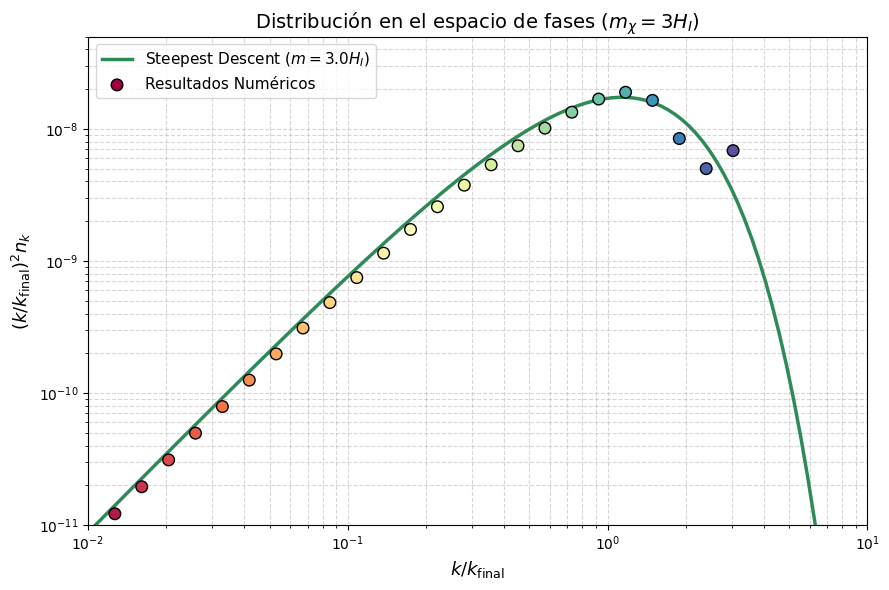


--- RESULTADO DE LA PRODUCCIÓN TOTAL ---
n_chi físico          = 2.122497e-10


In [11]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CARGA DE DATOS
# ============================================================
#Hi = 1 normalización de las simulaciones
H_inflacion = 1.0
a_final_infl = 1.0
t_final_infl = 60.0
m_chi = 3.0 * H_inflacion 

k_final_infl = a_final_infl * H_fnd(t_final_infl)

#archivo generado por el motor de integración
archivo_npz = f"datos_minkowski_m{m_chi}.npz"

if not os.path.exists(archivo_npz):
    print(f"Ojo: No veo el archivo {archivo_npz}. Hay que correr la simulación primero.")
    exit()

#extraemos los resultados numéricos
datos = np.load(archivo_npz, allow_pickle=True)
k_ratio_num = datos['k_ratio']
nk_num = datos['nk_final']

# ============================================================
# 2. FUNCIONES ANALÍTICAS (SD Y FONDO COMPLEJO)
# ============================================================
def omega2_compleja(t_c, k_v):
    #definición del fondo de minkowski para el plano complejo
    a_c = 2*a_final_infl*cmath.exp(H_inflacion*(t_c-t_final_infl)) / (1 + cmath.exp(H_inflacion*(t_c-t_final_infl)))
    H_c = H_inflacion/(1 + cmath.exp(H_inflacion*(t_c-t_final_infl)))
    Hd_c = -H_inflacion**2 * cmath.exp(H_inflacion*(t_c-t_final_infl)) / (1+cmath.exp(H_inflacion*(t_c-t_final_infl)))**2
    return k_v**2/a_c**2 + m_chi**2 - 2.25*H_c**2 - 1.5*Hd_c

def integral_Omega(tp, k):
    tR, tI = tp.real, tp.imag
    ys = np.linspace(0.0, abs(tI), 8000)
    ws = np.array([cmath.sqrt(omega2_compleja(tR - 1j*y, k)) for y in ys])
    
    # ========================================================
    # CONTROL DE CONTINUIDAD DE RAMA (Evita el colapso por signo)
    # ========================================================
    for i in range(1, len(ws)):
        if np.real(ws[i] * np.conj(ws[i-1])) < 0:
            ws[i] = -ws[i]
            
    #integral numérica para la fase (regla del trapecio)
    return -1j * np.trapezoid(ws, x=ys)

# ============================================================
# 3. CÁLCULO DE LA CURVA VERDE (Steepest Descent Dinámico)
# ============================================================
#generamos una malla fina para que la línea se vea suave
k_sd_eje = np.logspace(-2, 1.2, 120) * k_final_infl
results_sd = {}
#punto de inicio para el paseo del polo (en el centro para estabilidad)
idx_ref = len(k_sd_eje) // 2
semilla = np.array([t_final_infl, 1.5928]) 
    
print("Calculando rama de Steepest Descent (Paseo del Polo)...")
#barrido ir (hacia atrás)
z_temp = semilla.copy()
for i in range(idx_ref, -1, -1):
    kv = k_sd_eje[i]
    sol = root(lambda z: [omega2_compleja(z[0]+1j*z[1], kv).real, 
                          omega2_compleja(z[0]+1j*z[1], kv).imag], z_temp)
    if sol.success:
        z_temp = sol.x
        fase = integral_Omega(sol.x[0] + 1j*sol.x[1], kv)
        results_sd[i] = (np.pi**2 / 9.0) * np.exp(4.0 * fase.imag)
#barrido uv (hacia adelante)
z_temp = root(lambda z: [omega2_compleja(z[0]+1j*z[1], k_sd_eje[idx_ref]).real, 
                          omega2_compleja(z[0]+1j*z[1], k_sd_eje[idx_ref]).imag], semilla).x
for i in range(idx_ref + 1, len(k_sd_eje)):
    kv = k_sd_eje[i]
    sol = root(lambda z: [omega2_compleja(z[0]+1j*z[1], kv).real, 
                          omega2_compleja(z[0]+1j*z[1], kv).imag], z_temp)
    if sol.success:
        z_temp = sol.x
        fase = integral_Omega(sol.x[0] + 1j*sol.x[1], kv)
        results_sd[i] = (np.pi**2 / 9.0) * np.exp(4.0 * fase.imag)
nk_sd_curva = np.array([results_sd.get(i, np.nan) for i in range(len(k_sd_eje))]) 
# ============================================================
# 4. REPRESENTACIÓN
# ============================================================
#mantenemos el degradado spectral del otro código
#generamos los colores basados en la cantidad de datos cargados
n_modos = len(nk_num)
colores_spec = cm.Spectral(np.linspace(0, 1, n_modos))

#transformación a espacio de fases (k/k_f)^2 * n_k
y_num_fases = (k_ratio_num**2) * nk_num
y_teoria_fases = ((k_sd_eje/k_final_infl)**2) * nk_sd_curva

plt.figure(figsize=(9, 6))

#línea sd verde 
plt.loglog(k_sd_eje/k_final_infl, y_teoria_fases, color='seagreen', lw=2.5, 
           label=f"Steepest Descent ($m={m_chi/H_inflacion:.1f} H_I$)")


#usamos c=colores_spec para mantener el formato
plt.scatter(k_ratio_num, y_num_fases, c=colores_spec, edgecolor='black', 
            s=70, label="Resultados Numéricos", zorder=5)

#ajustes estéticos
plt.xlabel(r"$k/k_{\rm final}$", fontsize=13)
plt.ylabel(r"$(k/k_{\rm final})^2 n_k$", fontsize=13)
plt.title(r"Distribución en el espacio de fases ($m_\chi = 3 H_I$)", fontsize=14)

#límites 
plt.xlim(0.01, 10)
plt.ylim(1e-11, 5e-8)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, frameon=True)
plt.tight_layout()

#guardamos la gráfica 
plt.savefig(f"Espacio_Fases_Minkowski_m{m_chi}.png", dpi=300)
plt.show()

# ============================================================
# 5. VALOR DE LA INTEGRAL EN EL ESPACIO DE FASES (CORREGIDO)
# ============================================================
# Calculamos primero la densidad física real n_chi 
# Usamos el eje físico k_sd_eje y su diferencial dk para no perder el jacobiano
n_chi_real = (1.0 / (2 * np.pi**2)) * np.trapezoid(k_sd_eje**2 * nk_sd_curva, x=k_sd_eje)

# Ahora calculamos el valor normalizado respecto a k_final^3
n_normalizada_fases = n_chi_real / (k_final_infl**3)

print(f"\n--- RESULTADO DE LA PRODUCCIÓN TOTAL ---")
print(f"n_chi físico          = {n_chi_real:.6e}")

## $Ajuste \, Densidad \, Comóvil$

 Masa | Producción Total (n_chi)
----------------------------------------
  2.0 |         3.540259e-07
  2.5 |         7.873602e-09
  3.0 |         2.122505e-10
  3.5 |         6.537684e-12
  4.0 |         2.199118e-13
  4.5 |         7.845968e-15
  5.0 |         2.915400e-16
  5.5 |         1.115227e-17
  6.0 |         4.358412e-19
  6.5 |         1.731167e-20
  7.0 |         6.963268e-22
  7.5 |         2.828845e-23
  8.0 |         1.158464e-24


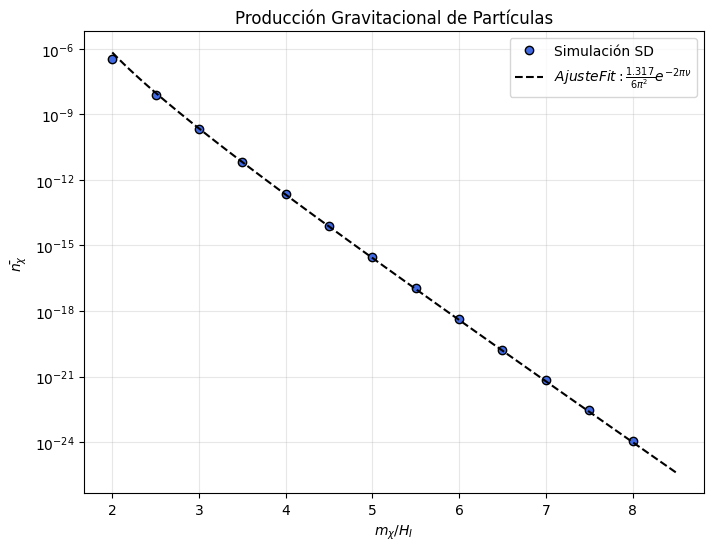

[INFO] Gráfica guardada como 'Fig3_Produccion_Total_Masas.pdf'


<Figure size 640x480 with 0 Axes>

In [14]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, curve_fit
from scipy.integrate import trapezoid
import cmath

# ============================================================
# 1. PARÁMETROS FÍSICOS Y CONFIGURACIÓN
# ============================================================
H_inflacion, t_final_infl = 1.0, 60.0
a_final_infl = 1.0
k_final_infl = a_final_infl * H_fnd(t_final_infl)

#malla de momentos k para la integral
k_ratio_eje = np.logspace(-2, 1.2, 120)
k_lista = k_ratio_eje * k_final_infl
masas = np.arange(2.0, 8.5, 0.5)

res_sd, errores = [], []


# ============================================================
# 2. DINÁMICA DE FONDO Y FUNCIONES ANALÍTICAS
# ============================================================
def a_fnd(t):
    return 2*a_final_infl*np.exp(H_inflacion*(t-t_final_infl))/(1+np.exp(H_inflacion*(t-t_final_infl)))

def omega2_compleja(t, k, m):
    #fondo de minkowski en el plano complejo
    a = 2*a_final_infl*cmath.exp(H_inflacion*(t-t_final_infl))/(1+cmath.exp(H_inflacion*(t-t_final_infl)))
    H = H_inflacion/(1+cmath.exp(H_inflacion*(t-t_final_infl)))
    Hd = -H_inflacion**2*cmath.exp(H_inflacion*(t-t_final_infl))/(1+cmath.exp(H_inflacion*(t-t_final_infl)))**2
    return k**2/a**2 + m**2 - 2.25*H**2 - 1.5*Hd

def integral_Omega(tp, k, m):
    tR, tI = tp.real, tp.imag
    ys = np.linspace(0, abs(tI), 6000)
    ws = np.array([cmath.sqrt(omega2_compleja(tR-1j*y, k, m)) for y in ys])
    
    #continuidad de rama
    for i in range(1, len(ws)):
        if np.real(ws[i]*np.conj(ws[i-1])) < 0:
            ws[i] = -ws[i]
            
    return -1j * trapezoid(ws, x=ys)

# ============================================================
# 3. BUCLE DE PRODUCCIÓN POR MASA (SD INTEGRADO)
# ============================================================
z_semilla = np.array([t_final_infl, 1.53])
mitad = len(k_lista) // 2

print(f"{'Masa':>5} | {'Producción Total (n_chi)':>20}")
print("-" * 40)

for m in masas:
    nk_dict = {}
    
    #punto de anclaje central para estabilidad
    sol0 = root(lambda z: [omega2_compleja(z[0]+1j*z[1], k_lista[mitad], m).real,
                            omega2_compleja(z[0]+1j*z[1], k_lista[mitad], m).imag], z_semilla)
    
    if not sol0.success:
        res_sd.append(np.nan)
        continue
        
    z_semilla = sol0.x
    
    #barrido ir (hacia atrás)
    z_tmp = z_semilla.copy()
    for i in range(mitad, -1, -1):
        k = k_lista[i]
        sol = root(lambda z: [omega2_compleja(z[0]+1j*z[1], k, m).real,
                                omega2_compleja(z[0]+1j*z[1], k, m).imag], z_tmp)
        if sol.success:
            z_tmp = sol.x
            fase = integral_Omega(z_tmp[0]+1j*z_tmp[1], k, m)
            nk_dict[i] = (np.pi**2/9.0)*np.exp(4*fase.imag)
            
    #barrido uv (hacia adelante)
    z_tmp = z_semilla.copy()
    for i in range(mitad+1, len(k_lista)):
        k = k_lista[i]
        sol = root(lambda z: [omega2_compleja(z[0]+1j*z[1], k, m).real,
                                omega2_compleja(z[0]+1j*z[1], k, m).imag], z_tmp)
        if sol.success:
            z_tmp = sol.x
            fase = integral_Omega(z_tmp[0]+1j*z_tmp[1], k, m)
            nk_dict[i] = (np.pi**2/9.0)*np.exp(4*fase.imag)
            
    #integración del espectro resultante
    idx_val = sorted(nk_dict.keys())
    ks = k_lista[idx_val]
    nks = np.array([nk_dict[i] for i in idx_val])
    
    if len(ks) < 5:
        res_sd.append(np.nan)
        continue
        
    n_total = (1/(2*np.pi**2))*trapezoid(ks**2*nks, x=ks)
    res_sd.append(n_total)
    
    print(f"{m:5.1f} | {n_total:20.6e}")
# ============================================================
# 4. AJUSTE LOGARÍTMICO Y MODELO DE DE SITTER
# ============================================================
masas_fit = np.array(masas)
res_fit = np.array(res_sd)
mask = np.isfinite(res_fit) & (res_fit > 0)
masas_fit, res_fit = masas_fit[mask], res_fit[mask]

def modelo_log(m, A):
    nu = np.sqrt(m**2 - 2.25)
    return np.log((A * k_final_infl**3 / (6*np.pi**2)) * np.exp(-2*np.pi*nu))

popt, _ = curve_fit(modelo_log, masas_fit, np.log(res_fit), p0=[1.3])
A_best = popt[0]

# --- Dibujo ---
plt.figure(figsize=(8, 6))
plt.semilogy(masas_fit, res_fit, 'o', color='royalblue', markeredgecolor='black', label='Simulación SD')

m_cont = np.linspace(2, 8.5, 100)
nu_cont = np.sqrt(m_cont**2 - 2.25)
# Escalar el ajuste por k^3 para que coincida con n_chi
n_teorico = (A_best * k_final_infl**3 / (6 * np.pi**2)) * np.exp(-2 * np.pi * nu_cont)


plt.semilogy(m_cont, n_teorico, 'k--', 
             label=fr'$Ajuste Fit: \frac{{{A_best:.3f}}}{{6\pi^2}} e^{{-2\pi\nu}}$')
plt.xlabel(r"$m_\chi / H_I$")
plt.ylabel(r"$\bar{n_{\chi}}$")
plt.title("Producción Gravitacional de Partículas")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
# Guardar la gráfica en PDF de alta calidad para la memoria
plt.savefig("Fig3_Produccion_Total_Masas.pdf", bbox_inches='tight')
print("[INFO] Gráfica guardada como 'Fig3_Produccion_Total_Masas.pdf'")

plt.show()

 Masa | Producción Total (n_chi)
----------------------------------------
  2.0 |         3.540259e-07
  2.5 |         7.873602e-09
  3.0 |         2.122505e-10
  3.5 |         6.537684e-12
  4.0 |         2.199118e-13
  4.5 |         7.845968e-15
  5.0 |         2.915400e-16
  5.5 |         1.115227e-17
  6.0 |         4.358412e-19
  6.5 |         1.731167e-20
  7.0 |         6.963268e-22
  7.5 |         2.828845e-23
  8.0 |         1.158464e-24

--- AJUSTE FINAL: A = 1.316811 ---
Figuras guardadas correctamente como 'Fig4_Escala_Inflacion.pdf' y 'Fig5_Temperatura_Recalentamiento.pdf'


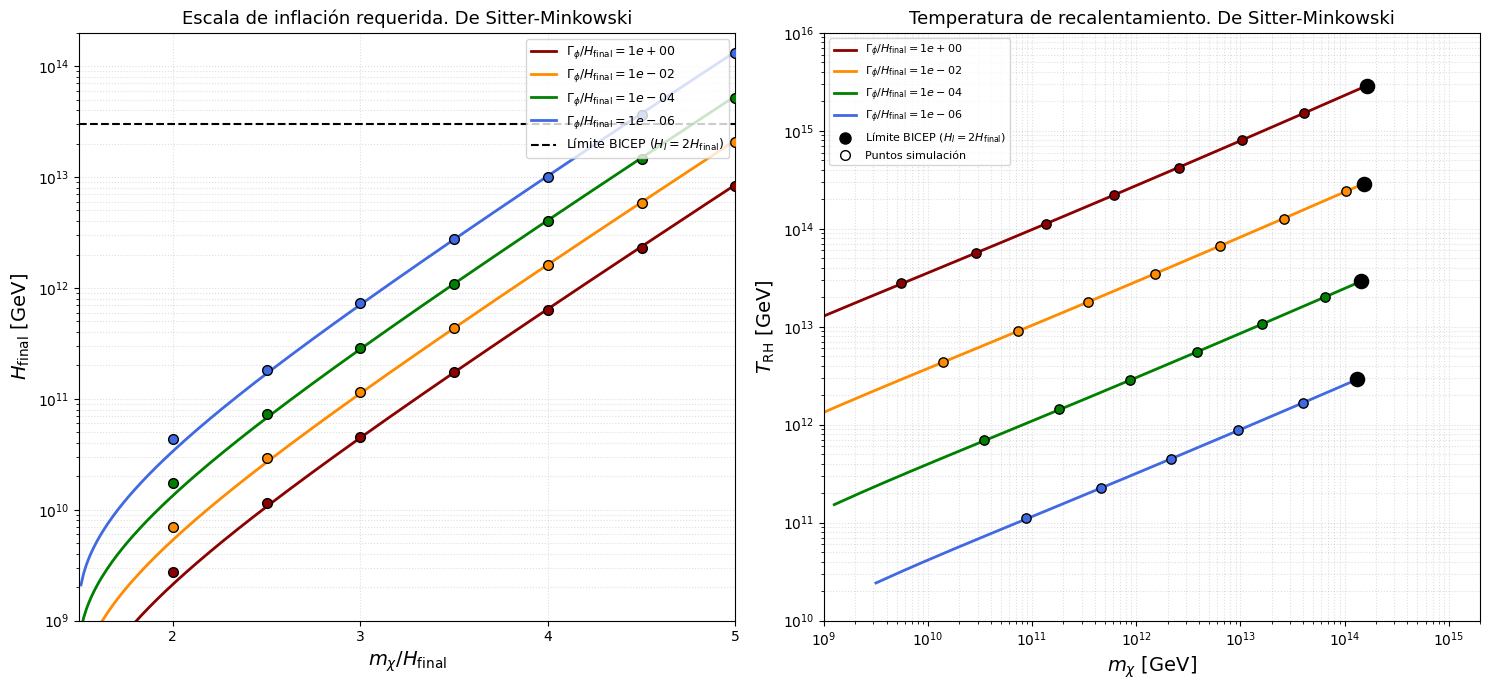

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, curve_fit
from scipy.integrate import trapezoid
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
import cmath

# ============================================================
# 1. PARÁMETROS FÍSICOS Y CONFIGURACIÓN
# ============================================================
h_inflacion, t_final_inflacion = 1.0, 60.0
a_final_inflacion = 1.0

# Función de Hubble para calcular k_final
def h_fondo(t):
    return h_inflacion / (1 + np.exp(h_inflacion * (t - t_final_inflacion)))

k_final_inflacion = a_final_inflacion * h_fondo(t_final_inflacion)

# Malla de momentos k para la integral del espacio de fases
ratios_k_eje = np.logspace(-2, 1.2, 120)
lista_k = ratios_k_eje * k_final_inflacion
lista_masas = np.arange(2.0, 8.5, 0.5)

resultados_sd = []

# ============================================================
# 2. DINÁMICA DE FONDO Y FUNCIONES ANALÍTICAS
# ============================================================
def a_fondo(t):
    # Factor de escala para la transición suave
    return 2*a_final_inflacion*np.exp(h_inflacion*(t-t_final_inflacion))/(1+np.exp(h_inflacion*(t-t_final_inflacion)))

def omega2_compleja(t, k, m):
    # Frecuencia extendida al plano complejo para buscar los polos
    a = 2*a_final_inflacion*cmath.exp(h_inflacion*(t-t_final_inflacion))/(1+cmath.exp(h_inflacion*(t-t_final_inflacion)))
    h = h_inflacion/(1+cmath.exp(h_inflacion*(t-t_final_inflacion)))
    hd = -h_inflacion**2*cmath.exp(h_inflacion*(t-t_final_inflacion))/(1+cmath.exp(h_inflacion*(t-t_final_inflacion)))**2
    return k**2/a**2 + m**2 - 2.25*h**2 - 1.5*hd

def integral_fase(tp, k, m):
    # Integral de la fase compleja en el plano imaginario
    tr, ti = tp.real, tp.imag
    ys = np.linspace(0, abs(ti), 6000)
    ws = np.array([cmath.sqrt(omega2_compleja(tr-1j*y, k, m)) for y in ys])
    
    # Corrección manual para la continuidad de la rama
    for i in range(1, len(ws)):
        if np.real(ws[i]*np.conj(ws[i-1])) < 0:
            ws[i] = -ws[i]
            
    return -1j * trapezoid(ws, x=ys)

# ============================================================
# 3. BUCLE DE PRODUCCIÓN POR MASA (SD INTEGRADO)
# ============================================================
semilla_z = np.array([t_final_inflacion, 1.53])
indice_mitad = len(lista_k) // 2

print(f"{'Masa':>5} | {'Producción Total (n_chi)':>20}")
print("-" * 40)

for m in lista_masas:
    dict_nk = {}
    
    # Busco el punto de anclaje central para asegurar estabilidad
    sol0 = root(lambda z: [omega2_compleja(z[0]+1j*z[1], lista_k[indice_mitad], m).real,
                            omega2_compleja(z[0]+1j*z[1], lista_k[indice_mitad], m).imag], semilla_z)
    
    if not sol0.success:
        resultados_sd.append(np.nan)
        continue
        
    semilla_z = sol0.x
    
    # Barrido hacia el infrarrojo (atrás)
    z_temporal = semilla_z.copy()
    for i in range(indice_mitad, -1, -1):
        k = lista_k[i]
        sol = root(lambda z: [omega2_compleja(z[0]+1j*z[1], k, m).real,
                                omega2_compleja(z[0]+1j*z[1], k, m).imag], z_temporal)
        if sol.success:
            z_temporal = sol.x
            fase = integral_fase(z_temporal[0]+1j*z_temporal[1], k, m)
            dict_nk[i] = (np.pi**2/9.0)*np.exp(4*fase.imag)
            
    # Barrido hacia el ultravioleta (adelante)
    z_temporal = semilla_z.copy()
    for i in range(indice_mitad+1, len(lista_k)):
        k = lista_k[i]
        sol = root(lambda z: [omega2_compleja(z[0]+1j*z[1], k, m).real,
                                omega2_compleja(z[0]+1j*z[1], k, m).imag], z_temporal)
        if sol.success:
            z_temporal = sol.x
            fase = integral_fase(z_temporal[0]+1j*z_temporal[1], k, m)
            dict_nk[i] = (np.pi**2/9.0)*np.exp(4*fase.imag)
            
    # Integro el espectro resultante para obtener la densidad comóvil
    indices_validos = sorted(dict_nk.keys())
    ks = lista_k[indices_validos]
    nks = np.array([dict_nk[i] for i in indices_validos])
    
    if len(ks) < 5:
        resultados_sd.append(np.nan)
        continue
        
    n_total = (1/(2*np.pi**2))*trapezoid(ks**2*nks, x=ks)
    resultados_sd.append(n_total)
    
    print(f"{m:5.1f} | {n_total:20.6e}")

# ============================================================
# 4. AJUSTE LOGARÍTMICO Y PREPARACIÓN DE DATOS
# ============================================================
masas_ajuste = np.array(lista_masas)
res_ajuste = np.array(resultados_sd)
mascara = np.isfinite(res_ajuste) & (res_ajuste > 0)
masas_ajuste, res_ajuste = masas_ajuste[mascara], res_ajuste[mascara]

def modelo_logaritmico(m, parametro_a):
    nu = np.sqrt(m**2 - 2.25)
    return np.log((parametro_a * k_final_inflacion**3 / (6*np.pi**2)) * np.exp(-2*np.pi*nu))

popt, pcov = curve_fit(modelo_logaritmico, masas_ajuste, np.log(res_ajuste), p0=[1.3])
a_mejor_ajuste = popt[0]

print(f"\n--- AJUSTE FINAL: A = {a_mejor_ajuste:.6f} ---")

# Variables para las figuras de abundancia
resultados_validos = res_ajuste / k_final_inflacion**3   # Normalización n_barra
masas_validas = masas_ajuste
masas_malla_fina = np.linspace(1.51, 8.5, 500)
nu_malla_fina = np.sqrt(masas_malla_fina**2 - 2.25)
n_comovil_ajuste = (a_mejor_ajuste / (6.0 * np.pi**2)) * np.exp(-2.0 * np.pi * nu_malla_fina)

g_star = 106.75
# ============================================================
# 5. FÓRMULAS DE ABUNDANCIA DE MATERIA OSCURA
# ============================================================
def H_final_desde_abundancia(n_bar, mu, r_gamma):
    # Normalización de grados de libertad para Starobinsky
    g_factor = (g_star / 106.75)**(-0.25)
    
    # Despeje de H_end desde la abundancia observada
    term_n = n_bar / 6e-10
    term_gamma = np.sqrt(r_gamma / 1e-3)
    brackets = (0.12 * g_factor) / (term_n * mu * term_gamma)
    return 1e12 * np.power(brackets, 0.4)


def T_rh_desde_H_final(h_final, r_gamma):
    Gamma = r_gamma * h_final
    return 1.7e15 * g_star**(-0.25) * np.sqrt(Gamma / 1e12)
# ============================================================
# 6. FIGURAS — panel derecho truncado en el límite BICEP
# ============================================================
ratios_gamma  = [1.0, 1e-2, 1e-4, 1e-6]
colores       = ['darkred', 'darkorange', 'green', 'royalblue']
H_I_max_bicep = 6e13  # GeV (límite BICEP/Planck)
ratio_HI      = 2     # Tu punto de corte H_I = 2 * H_final
H_final_max   = H_I_max_bicep / ratio_HI

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# ---- PANEL IZQUIERDO: H_final vs μ = mχ/H_final ----
for r_gamma, color in zip(ratios_gamma, colores):
    etiqueta = rf'$\Gamma_\phi/H_{{\rm final}} = {r_gamma:.0e}$'
    H_final_sim = H_final_desde_abundancia(resultados_validos, masas_validas, r_gamma)
    ax1.semilogy(masas_validas, H_final_sim, marker='o', ls='', color=color,
                 markersize=7, markeredgecolor='black', zorder=5)
    H_final_curva = H_final_desde_abundancia(n_comovil_ajuste, masas_malla_fina, r_gamma)
    ax1.semilogy(masas_malla_fina, H_final_curva, color=color, lw=2, label=etiqueta)

ax1.axhline(H_final_max, color='black', ls='--', lw=1.5, label=r'Límite BICEP ($H_I = 2H_{\rm final}$)')
ax1.set_xlim(1.5, 5.0)
ax1.set_ylim(1e9, 2e14)
ax1.set_xlabel(r'$m_\chi / H_{\rm final}$', fontsize=14)
ax1.set_ylabel(r'$H_{\rm final}\ [\mathrm{GeV}]$', fontsize=14)
ax1.set_title(r'Escala de inflación requerida. De Sitter-Minkowski', fontsize=13)
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.set_xticks([2, 3, 4, 5])
ax1.grid(True, which='both', ls=':', alpha=0.4)
ax1.legend(fontsize=9, frameon=True, loc='upper right')

# ---- PANEL DERECHO: T_rh vs mχ [GeV] ----
for r_gamma, color in zip(ratios_gamma, colores):
    etiqueta = rf'$\Gamma_\phi/H_{{\rm final}} = {r_gamma:.0e}$'
    
    H_final_curva = H_final_desde_abundancia(n_comovil_ajuste, masas_malla_fina, r_gamma)
    T_rh_curva  = T_rh_desde_H_final(H_final_curva, r_gamma)
    m_chi_curva = masas_malla_fina * H_final_curva
    
    # --- CAMBIO CLAVE: Máscara para detener la gráfica en el límite ---
    # Solo graficamos donde H_final es menor o igual al límite permitido
    mascara_valida = H_final_curva <= H_final_max
    
    ax2.loglog(m_chi_curva[mascara_valida], T_rh_curva[mascara_valida], 
               color=color, lw=2, label=etiqueta)

    # Puntos de simulación (también filtrados por el límite)
    H_final_sim = H_final_desde_abundancia(resultados_validos, masas_validas, r_gamma)
    T_rh_sim  = T_rh_desde_H_final(H_final_sim, r_gamma)
    m_chi_sim = masas_validas * H_final_sim
    mascara_sim_valida = H_final_sim <= H_final_max
    
    ax2.scatter(m_chi_sim[mascara_sim_valida], T_rh_sim[mascara_sim_valida],
                color=color, marker='o', edgecolors='black', s=45, zorder=5)

    # Marcador final (punto de corte)
    idx_limite = np.argmin(np.abs(H_final_curva - H_final_max))
    T_limite   = T_rh_desde_H_final(H_final_max, r_gamma)
    m_limite   = masas_malla_fina[idx_limite] * H_final_max
    ax2.scatter(m_limite, T_limite, color='black', marker='o', s=100,
                edgecolors='black', linewidths=1.2, zorder=6)

ax2.set_xlim(1e9, 2e15)
ax2.set_ylim(1e10, 1e16)
ax2.set_xlabel(r'$m_\chi\ [\mathrm{GeV}]$', fontsize=14)
ax2.set_ylabel(r'$T_{\rm RH}\ [\mathrm{GeV}]$', fontsize=14)
ax2.set_title(r'Temperatura de recalentamiento. De Sitter-Minkowski', fontsize=13)
ax2.grid(True, which='both', ls=':', alpha=0.4)

# Leyenda corregida en español
manejadores, etiquetas = ax2.get_legend_handles_labels()
extras = [
    Line2D([0],[0], marker='o', color='black', ls='', ms=8,
           markeredgecolor='black', label=r'Límite BICEP ($H_I = 2 H_{\rm final}$)'),
    Line2D([0],[0], marker='o', color='w', ls='', ms=7,
           markeredgecolor='black', label='Puntos simulación'),
]
ax2.legend(handles=manejadores[:4]+extras,
           labels=etiquetas[:4]+[e.get_label() for e in extras],
           fontsize=8, frameon=True, loc='upper left')

plt.tight_layout()

bbox_ax1 = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)
bbox_ax2 = ax2.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

plt.savefig("Fig4_Escala_Inflacion.pdf", bbox_inches=bbox_ax1)
plt.savefig("Fig5_Temperatura_Recalentamiento.pdf", bbox_inches=bbox_ax2)

print("Figuras guardadas correctamente como 'Fig4_Escala_Inflacion.pdf' y 'Fig5_Temperatura_Recalentamiento.pdf'")
plt.show()


# $STAROBINSKY$

## $\alpha=1$

### $M=2H_{(N=60)}$

--- Calibrando fondo para alpha=1.0 y N=60.0 ---
Calibración exitosa: phi0 = 5.4160 | t_final = 63.03
--- Integrando Starobinsky (alpha=1.0, Adiabacidad=1.0e-04) ---
Modo  | k/k_final  | t_inicio     | nk Final     | Precisión(Wr)  | Estado
-------------------------------------------------------------------------------------
1     | 1.00e-07   | 34.51        | 4.20e-03     | 1.6e-09        | PRECISO
2     | 1.46e-07   | 34.90        | 3.56e-03     | 1.6e-09        | PRECISO
3     | 2.12e-07   | 35.28        | 2.36e-03     | 1.6e-09        | PRECISO
4     | 3.09e-07   | 35.67        | 1.88e-03     | 1.6e-09        | PRECISO
5     | 4.50e-07   | 36.06        | 2.61e-03     | 1.6e-09        | PRECISO
6     | 6.55e-07   | 36.44        | 3.77e-03     | 1.6e-09        | PRECISO
7     | 9.54e-07   | 36.83        | 4.10e-03     | 1.6e-09        | PRECISO
8     | 1.39e-06   | 37.22        | 3.26e-03     | 1.6e-09        | PRECISO
9     | 2.02e-06   | 37.61        | 2.17e-03     | 1.6e-09       

NameError: name 'mchi' is not defined

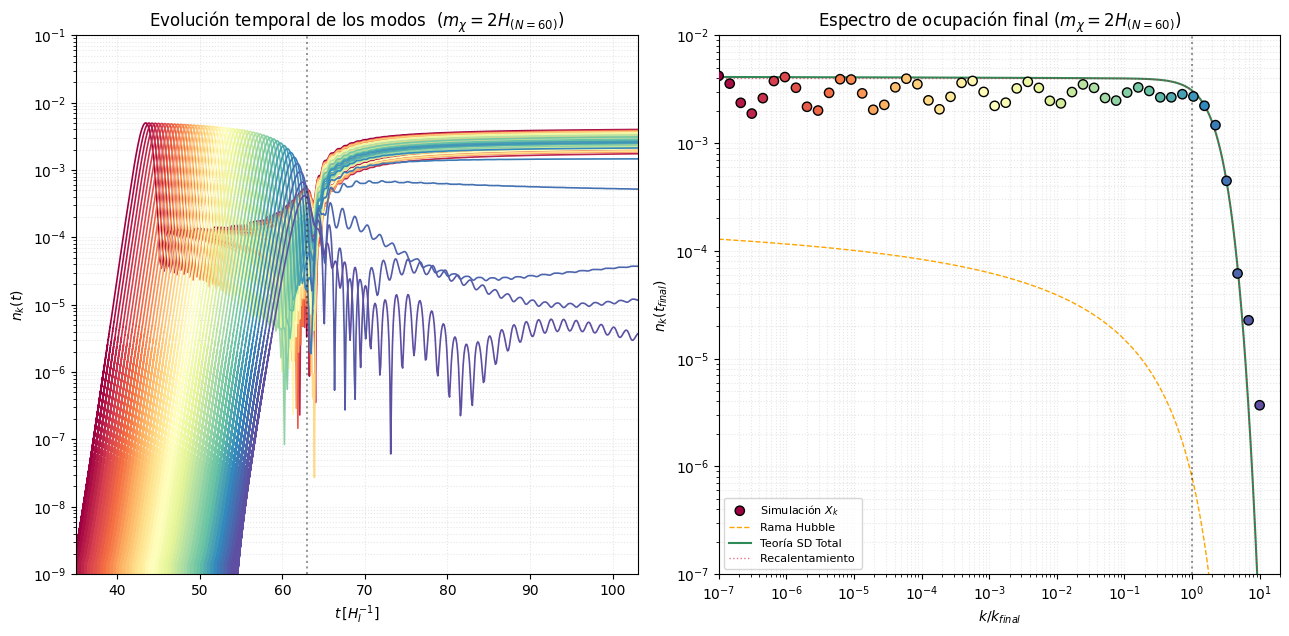

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, brentq, minimize
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CONFIGURACIÓN
# ============================================================
M_planck, H_inflacion = 1.0, 1.0 #normalización de rigor
alpha = 1.0          #parámetro principal de starobinsky
m_chi = 2.0 * H_inflacion  #masa de la partícula pesada
lambda_pot = (2 * H_inflacion)**2
N_objetivo = 60.0    #queremos los 60 e-folds de rigor
t_final_sim = 200.0  

#masa del inflatón y coeficiente del potencial según el alpha elegido
m_phi = (2.0 * H_inflacion) / np.sqrt(alpha) 
b_pot = np.sqrt(2 / (3 * alpha))

#ajustes de precisión para no perder la fase en los modos UV
objetivo_adiabatico = 1e-4
tol_rel, tol_abs = 1e-11, 1e-13

# ============================================================
# 2. DINÁMICA DE FONDO Y CALIBRACIÓN DE E-FOLDS
# ============================================================
def potencial_V(phi): 
    return 0.75 * lambda_pot * (1 - np.exp(-b_pot * phi))**2

def derivada_V(phi): 
    return 1.5 * b_pot * lambda_pot * (1 - np.exp(-b_pot * phi)) * np.exp(-b_pot * phi)

def ecuaciones_fondo(t, y):
    phi, phi_punto, log_a = y
    H = np.sqrt((0.5 * phi_punto**2 + potencial_V(phi)) / 3.0)
    return [phi_punto, -3 * H * phi_punto - derivada_V(phi), H]

def cuenta_efolds(p0):
    #simulación para contar cuánta inflación genera una phi0 dada
    sol_bg = solve_ivp(ecuaciones_fondo, (0, 10000), [p0, 0, 0], rtol=1e-8)
    H = np.sqrt((0.5 * sol_bg.y[1]**2 + potencial_V(sol_bg.y[0])) / 3.0)
    epsilon = (sol_bg.y[1]**2) / (2 * H**2)
    idx_final = np.where(epsilon >= 1.0)[0]
    return sol_bg.y[2][idx_final[0]] if len(idx_final) > 0 else 0

print(f"--- Calibrando fondo para alpha={alpha} y N={N_objetivo} ---")

#--- buscador dinámico de rango para generalizar cualquier alpha ---
def encontrar_bracket(objetivo):
    #estimación basada en la analítica de starobinsky
    phi_guia = (1/b_pot) * np.log(4*objetivo/(3*alpha))
    a, b = phi_guia * 0.5, phi_guia * 1.5
    while (cuenta_efolds(a) - objetivo) > 0 and a > 0.1:
        a /= 1.2
    while (cuenta_efolds(b) - objetivo) < 0 and b < 50:
        b *= 1.2
    return a, b

p_min, p_max = encontrar_bracket(N_objetivo)
phi0_exacto = brentq(lambda p: cuenta_efolds(p) - N_objetivo, p_min, p_max)

#integración final del fondo con la phi0 encontrada
sol_fondo = solve_ivp(ecuaciones_fondo, (0, 500), [phi0_exacto, 0, 0], 
                      t_eval=np.linspace(0, 500, 20000), rtol=tol_rel, atol=tol_abs)

t_fnd, a_fnd_val = sol_fondo.t, np.exp(sol_fondo.y[2])
H_fnd_val = np.sqrt((0.5 * sol_fondo.y[1]**2 + potencial_V(sol_fondo.y[0])) / 3.0)
H_punto_fnd_val = - (sol_fondo.y[1]**2) / 2.0

#localización exacta del fin de inflación
idx_final_inflacion = np.argmax((sol_fondo.y[1]**2 / (2 * H_fnd_val**2)) > 1.0)
t_final_infl = t_fnd[idx_final_inflacion]
k_final_infl = a_fnd_val[idx_final_inflacion] * H_fnd_val[idx_final_inflacion]

#interpoladores (motor para el cálculo de modos)
interp_a = interp1d(t_fnd, a_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H = interp1d(t_fnd, H_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H_punto = interp1d(t_fnd, H_punto_fnd_val, kind='cubic', fill_value="extrapolate")
H_final = H_fnd_val[idx_final_inflacion]
a_final = a_fnd_val[idx_final_inflacion]

print(f"Calibración exitosa: phi0 = {phi0_exacto:.4f} | t_final = {t_final_infl:.2f}")

#clave para las semillas analíticas: tiempo de cruce de horizonte
aH_fnd = a_fnd_val * H_fnd_val
interp_tiempo_cruce = interp1d(np.log(aH_fnd), t_fnd, kind='linear', fill_value="extrapolate")

# ============================================================
# 3. INTEGRACIÓN NUMÉRICA DE MODOS Y CONTROL DE CALIDAD
# ============================================================
def omega2_numerico(t, k):
    #frecuencia efectiva usando el fondo calibrado de starobinsky
    return k**2/interp_a(t)**2 + m_chi**2 - 2.25*interp_H(t)**2 - 1.5*interp_H_punto(t)

def calc_adiabaticidad(t, k):
    w2 = np.maximum(omega2_numerico(t, k), 1e-30)
    w = np.sqrt(w2)
    dt = 1e-4
    w_der = (np.sqrt(np.maximum(omega2_numerico(t+dt, k), 1e-30)) - 
             np.sqrt(np.maximum(omega2_numerico(t-dt, k), 1e-30))) / (2*dt)
    return np.abs(w_der / w2)

#malla de momentos k
k_lista = np.logspace(-7, 1, 50) * k_final_infl
#k_lista = k_lista[[6,10,47,48,49]] #comprobaciones
nk_final_lista, lista_evolucion_nk, lista_tiempos, wr_err_lista = [], [], [], []

print(f"--- Integrando Starobinsky (alpha={alpha}, Adiabacidad={objetivo_adiabatico:.1e}) ---")
print(f"{'Modo':<5} | {'k/k_final':<10} | {'t_inicio':<12} | {'nk Final':<12} | {'Precisión(Wr)':<14} | {'Estado'}")
print("-" * 85)

for i, k in enumerate(k_lista):
    try: 
        t_ini = brentq(lambda t: calc_adiabaticidad(t, k) - objetivo_adiabatico, 0.1, t_final_infl - 2.0)
    except: 
        t_ini = 10.0 
    
    t_inicio_modo = t_ini

    #c.i. WKB (orden 1)
    w0 = np.sqrt(np.maximum(omega2_numerico(t_inicio_modo, k), 1e-30))
    X0 = 1.0 / np.sqrt(2.0 * w0)
    deps = 1e-5
    w_der0 = (np.sqrt(np.maximum(omega2_numerico(t_inicio_modo+deps, k), 1e-30)) - 
              np.sqrt(np.maximum(omega2_numerico(t_inicio_modo-deps, k), 1e-30))) / (2*deps)
    X_der0 = (-w_der0 / (4.0 * w0) - 1j * w0) * X0
    
    #integración con DOP853
    sol = solve_ivp(lambda t, y: [y[2], y[3], -omega2_numerico(t, k)*y[0], -omega2_numerico(t, k)*y[1]], 
                    (t_inicio_modo, t_final_sim), [X0.real, X0.imag, X_der0.real, X_der0.imag], 
                    method='DOP853', rtol=tol_rel, atol=tol_abs)
    
    #cálculo del wronskiano
    X_n = sol.y[0] + 1j*sol.y[1]
    Xd_n = sol.y[2] + 1j*sol.y[3]
    wr_err = np.max(np.abs(X_n * np.conj(Xd_n) - np.conj(X_n) * Xd_n - 1j))
    
    #cálculo de nk asintótico
    w_eval = np.sqrt(np.maximum(omega2_numerico(sol.t, k), 1e-30))
    nk_evol = (np.abs(Xd_n)**2 + w_eval**2 * np.abs(X_n)**2) / (2.0 * w_eval) - 0.5
    
    #media del tramo final para evitar oscilaciones
    num_puntos = len(nk_evol)
    diez_por_ciento = max(1, int(num_puntos * 0.01))
    nk_final_val = np.mean(nk_evol[-diez_por_ciento:]).real

    #--- lógica de discriminación ---
    if nk_final_val < wr_err:
        display_nk = "Bajo Ruido"
        nk_to_save = np.nan 
        status = "IMPRECISO (DESCARTADO)"
    else:
        display_nk = f"{nk_final_val:.2e}"
        nk_to_save = nk_final_val
        status = "PRECISO"

    nk_final_lista.append(nk_to_save)
    wr_err_lista.append(wr_err)
    lista_evolucion_nk.append(nk_evol.real)
    lista_tiempos.append(sol.t)

    #print informativo perfectamente alineado
    print(f"{i+1:<5d} | {k/k_final_infl:<10.2e} | {t_inicio_modo:<12.2f} | {display_nk:<12} | {wr_err:<14.1e} | {status}")

    #guardado dinámico
    np.savez(f"datos_starobinsky_alpha{alpha}_m_chi{m_chi}.npz", 
             k_ratio=k_lista[:i+1]/k_final_infl, 
             nk_final=nk_final_lista, 
             wr_errors=wr_err_lista,
             times=np.array(lista_tiempos, dtype=object), 
             nk_evolutions=np.array(lista_evolucion_nk, dtype=object))

# ============================================================
# 4. VALIDACIÓN ANALÍTICA (Steepest Descent)
# ============================================================
def omega2_compleja(t_c, k_v):
    tr, ti = t_c.real, t_c.imag
    ar, hr, hdr = interp_a(tr), interp_H(tr), interp_H_punto(tr)
    a2_complejo = (ar**2) * cmath.exp(2j * hr * ti)
    return k_v**2 / a2_complejo + m_chi**2 - 2.25 * hr**2 - 1.5 * hdr

def rama_hubble_analitica(ki, polo_previo):
    #semilla según tiempo de cruce
    try: t_semilla = min(float(interp_tiempo_cruce(np.log(ki))), t_final_infl - 0.1)
    except: t_semilla = t_final_infl - 5.0
    
    res = minimize(lambda x: np.abs(omega2_compleja(x[0] + 1j * x[1], ki)), 
                    [t_semilla, 1.95 if polo_previo is None else polo_previo.imag], 
                    method='Nelder-Mead', tol=1e-15)
    tp = res.x[0] + 1j * res.x[1]
    
    if res.fun < 1e-11 and tp.real < t_final_infl + 2.0:
        ys = np.linspace(0, abs(tp.imag), 3000)
        ws = [cmath.sqrt(omega2_compleja(tp.real + 1j * y, ki)) for y in ys]
        for j in range(1, len(ws)):
            if np.real(ws[j] * np.conj(ws[j-1])) < 0: ws[j] = -ws[j]
        integral = np.trapezoid(ws, ys)
        return (np.pi**2 / 9.0) * np.exp(-4.0 * np.abs(integral.real)), tp
    return np.nan, polo_previo

def rama_recalentamiento_analitica(ki, z0):
    #potencial oscilatorio tras inflación
    w2_recal = lambda t_c: (ki**2 / a_final**2) + m_chi**2 - (1.125 * H_final**2 * cmath.cos(2.0 * m_phi * t_c))
    tp = 1j * (1.0 / (2.0 * m_phi)) * np.log((16.0/9.0) * (m_chi**2 / H_final**2))
    ys = np.linspace(0, abs(tp.imag), 2000)
    ws = np.array([cmath.sqrt(w2_recal(tp.real + 1j*y)) for y in ys])
    integral = np.trapezoid(ws.real, ys)
    return (np.pi**2 / 9.0) * np.exp(-4.0 * integral), tp

#ejecución de la validación
k_ir = np.logspace(-7, 0.000001, 100)   # Zona de salida de horizonte
k_uv = np.linspace(0.01, 15.0, 500)
k_ratios_analitico = np.sort(np.unique(np.concatenate([k_ir, k_uv])))
nk_hubble, nk_preheat = [], []
polo_h, polo_p = None, [0.0, (1.0 / (2.0 * m_phi)) * np.log((16/9* m_chi**2 / H_final**2))]

print("\n--- Calculando curvas de Steepest Descent ---")
for kr in k_ratios_analitico:
    ki = kr * k_final_infl
    val_h, polo_h = rama_hubble_analitica(ki, polo_h)
    nk_hubble.append(val_h)
    val_p, tp_p_comp = rama_recalentamiento_analitica(ki, [polo_p[0], polo_p[1]])
    polo_p = [tp_p_comp.real, tp_p_comp.imag]
    nk_preheat.append(val_p)

#unión de ramas
mask_h = (~np.isnan(nk_hubble)) & (np.array(nk_hubble) > 0)
interp_h = interp1d(np.log10(k_ratios_analitico[mask_h]), np.log10(np.array(nk_hubble)[mask_h]), 
                    kind='linear', fill_value="extrapolate")
hubble_finalizado = 10**interp_h(np.log10(k_ratios_analitico))
hubble_finalizado[k_ratios_analitico > k_ratios_analitico[mask_h][-1] * 1.2] = np.nan
nk_total_teoria = np.nan_to_num(hubble_finalizado) + np.array(nk_preheat)

# ============================================================
# 5. PANEL DE RESULTADOS FINAL 
# ============================================================
colores_spec = cm.Spectral(np.linspace(0, 1, len(nk_final_lista)))

fig = plt.figure(figsize=(13, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0, 0])    #arriba izq: evolución
ax2 = fig.add_subplot(gs[0, 1])    #arriba der: espectro n_k

#--- panel 1: evolución temporal ---
for i in range(len(nk_final_lista)):
    ax1.plot(lista_tiempos[i], np.maximum(lista_evolucion_nk[i], 1e-40), color=colores_spec[i], lw=1.2)
ax1.set_yscale('log')
ax1.set_xlim(35, t_final_infl + 40)
ax1.axvline(t_final_infl, color='black', ls=':', alpha=0.4, label='Fin Inflación')
ax1.set_xlim(35, t_final_infl + 40)
ax1.set_ylim(1e-9, 1e-1)
ax1.set_xlabel(r'$t\,[H_I^{-1}]$')
ax1.set_ylabel(r'$n_k(t)$')
ax1.set_title(r'Evolución temporal de los modos  ($m_\chi = 2 H_{(N=60)}$)')
ax1.grid(True, which='both', ls=':', alpha=0.3)

#--- panel 2: espectro estándar ---
ax2.scatter(k_lista/k_final_infl, np.maximum(nk_final_lista, 1e-40), 
               c=colores_spec, edgecolor='black', s=45, zorder=5, label=r'Simulación $X_k$')
ax2.loglog(k_ratios_analitico, hubble_finalizado, color='orange', ls='--', lw=1.0, label='Rama Hubble')
ax2.loglog(k_ratios_analitico, nk_total_teoria, color='seagreen', ls='-', lw=1.5, label='Teoría SD Total')
ax2.loglog(k_ratios_analitico, nk_preheat, color='crimson', ls=':', lw=1.0, alpha=0.6, label='Recalentamiento ')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(1e-7, 1e-2)
ax2.set_xlim(1e-7, 20)
ax2.axvline(1.0, color='black', ls=':', alpha=0.4)
ax2.set_xlabel(r'$k/k_{final}$')
ax2.set_ylabel(r'$n_k(t_{final})$')
ax2.set_title(r'Espectro de ocupación final ($m_\chi = 2 H_{(N=60)}$)')
ax2.legend(fontsize=8, loc='lower left', frameon=True)
ax2.grid(True, which='both', ls=':', alpha=0.3)


plt.tight_layout()
bbox_ax1 = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)
bbox_ax2 = ax2.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# Guardar de forma independiente cada panel recortado
plt.savefig(f"Fig6_Evolucion_Modos_Starobinsky_alpha{alpha}_m{mchi}H_I.pdf", bbox_inches=bbox_ax1)
plt.savefig(f"Fig7_Espectro_Final_Starobinsky_alpha{alpha}_m{mchi}H_I.pdf", bbox_inches=bbox_ax2)

print(f"Figuras guardadas: 'Fig6_Evolucion_Modos_Starobinsky_alpha{alpha}_m{mchi}H_I.pdf' y 'Fig7_Espectro_Final_Starobinsky_alpha{alpha}_m{mchi}H_I.pdf'")
plt.show()
plt.show()


--- Calibrando fondo para alpha=1.0 y N=60.0 ---
Calibración exitosa: phi0 = 5.4160 | t_final = 63.03
Calculando rama de Steepest Descent (Paseo del Polo)...


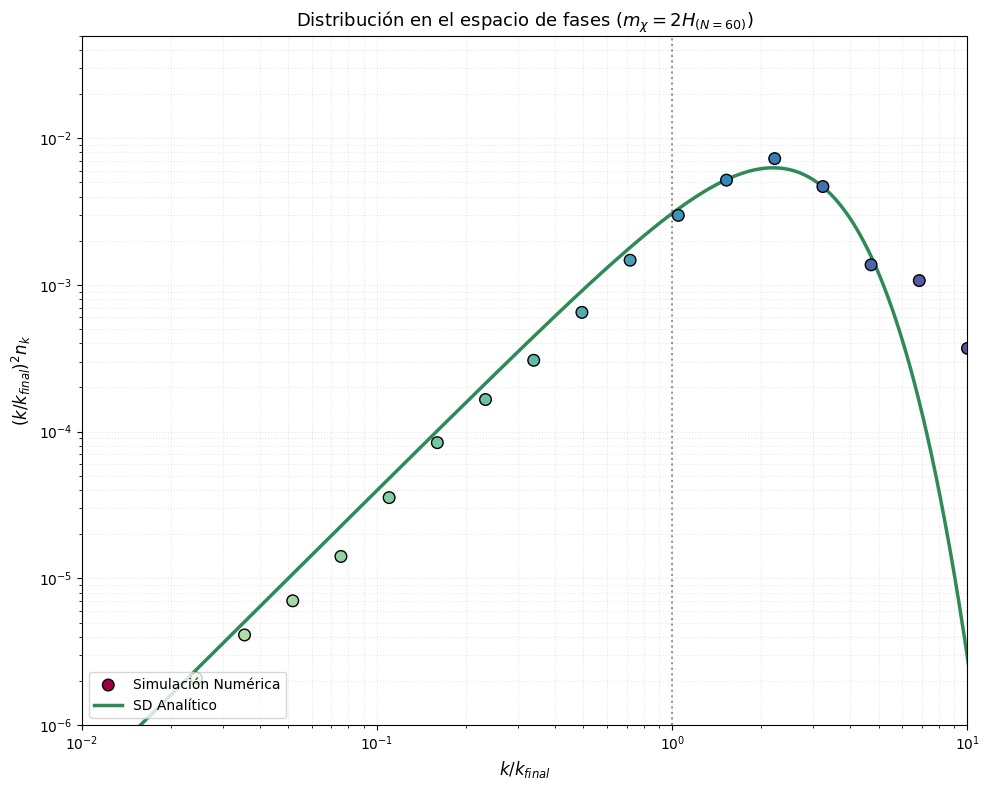


--- RESULTADO DE LA PRODUCCIÓN TOTAL ---
n_chi / k_final^3 = 9.692016e-04 m_chi/H_(N=60)
Gráfico exportado correctamente como: 'Fig8_Espacio_Fases_Starobinsky_alpha1.0_mchi2.0.pdf'


<Figure size 640x480 with 0 Axes>

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, brentq, minimize
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CONFIGURACIÓN
# ============================================================
M_planck, H_inflacion = 1.0, 1.0 #normalización de rigor
alpha = 1.0          #parámetro principal de starobinsky
m_chi = 2.0 * H_inflacion  #masa de la partícula pesada
lambda_pot = (2 * H_inflacion)**2
N_objetivo = 60.0    #queremos los 60 e-folds de rigor
t_final_sim = 150.0  

#masa del inflatón y coeficiente del potencial según el alpha elegido
m_phi = (2.0 * H_inflacion) / np.sqrt(alpha) 
b_pot = np.sqrt(2 / (3 * alpha))

#ajustes de precisión para no perder la fase en los modos UV
objetivo_adiabatico = 1e-4
tol_rel, tol_abs = 1e-11, 1e-13

# ============================================================
# 2. DINÁMICA DE FONDO Y CALIBRACIÓN DE E-FOLDS
# ============================================================
def potencial_V(phi): 
    return 0.75 * lambda_pot * (1 - np.exp(-b_pot * phi))**2

def derivada_V(phi): 
    return 1.5 * b_pot * lambda_pot * (1 - np.exp(-b_pot * phi)) * np.exp(-b_pot * phi)

def ecuaciones_fondo(t, y):
    phi, phi_punto, log_a = y
    H = np.sqrt((0.5 * phi_punto**2 + potencial_V(phi)) / 3.0)
    return [phi_punto, -3 * H * phi_punto - derivada_V(phi), H]

def cuenta_efolds(p0):
    #simulación para contar cuánta inflación genera una phi0 dada
    sol_bg = solve_ivp(ecuaciones_fondo, (0, 10000), [p0, 0, 0], rtol=1e-8)
    H = np.sqrt((0.5 * sol_bg.y[1]**2 + potencial_V(sol_bg.y[0])) / 3.0)
    epsilon = (sol_bg.y[1]**2) / (2 * H**2)
    idx_final = np.where(epsilon >= 1.0)[0]
    return sol_bg.y[2][idx_final[0]] if len(idx_final) > 0 else 0

print(f"--- Calibrando fondo para alpha={alpha} y N={N_objetivo} ---")

#--- buscador dinámico de rango para generalizar cualquier alpha ---
def encontrar_bracket(objetivo):
    #estimación basada en la analítica de starobinsky
    phi_guia = (1/b_pot) * np.log(4*objetivo/(3*alpha))
    a, b = phi_guia * 0.5, phi_guia * 1.5
    while (cuenta_efolds(a) - objetivo) > 0 and a > 0.1:
        a /= 1.2
    while (cuenta_efolds(b) - objetivo) < 0 and b < 50:
        b *= 1.2
    return a, b

p_min, p_max = encontrar_bracket(N_objetivo)
phi0_exacto = brentq(lambda p: cuenta_efolds(p) - N_objetivo, p_min, p_max)

#integración final del fondo con la phi0 encontrada
sol_fondo = solve_ivp(ecuaciones_fondo, (0, 500), [phi0_exacto, 0, 0], 
                      t_eval=np.linspace(0, 500, 20000), rtol=tol_rel, atol=tol_abs)

t_fnd, a_fnd_val = sol_fondo.t, np.exp(sol_fondo.y[2])
H_fnd_val = np.sqrt((0.5 * sol_fondo.y[1]**2 + potencial_V(sol_fondo.y[0])) / 3.0)
H_punto_fnd_val = - (sol_fondo.y[1]**2) / 2.0

#localización exacta del fin de inflación
idx_final_inflacion = np.argmax((sol_fondo.y[1]**2 / (2 * H_fnd_val**2)) > 1.0)
t_final_infl = t_fnd[idx_final_inflacion]
k_final_infl = a_fnd_val[idx_final_inflacion] * H_fnd_val[idx_final_inflacion]

#interpoladores
interp_a = interp1d(t_fnd, a_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H = interp1d(t_fnd, H_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H_punto = interp1d(t_fnd, H_punto_fnd_val, kind='cubic', fill_value="extrapolate")
H_final = H_fnd_val[idx_final_inflacion]
a_final = a_fnd_val[idx_final_inflacion]

print(f"Calibración exitosa: phi0 = {phi0_exacto:.4f} | t_final = {t_final_infl:.2f}")

#clave para las semillas analíticas: tiempo de cruce de horizonte
aH_fnd = a_fnd_val * H_fnd_val
interp_tiempo_cruce = interp1d(np.log(aH_fnd), t_fnd, kind='linear', fill_value="extrapolate")

# ============================================================
# 3. RECOGIDA DE MODOS NUMÉRICOS ANTERIORES
# ============================================================
#cargamos los datos generados en la simulación previa
datos = np.load(f"datos_starobinsky_alpha{alpha}_m_chi{m_chi}.npz", allow_pickle=True)
k_lista = datos['k_ratio'] * k_final_infl
nk_final_lista = datos['nk_final']

# ============================================================
# 4. VALIDACIÓN ANALÍTICA (Steepest Descent)
# ============================================================
def omega2_compleja(t_c, k_v):
    tr, ti = t_c.real, t_c.imag
    ar, hr, hdr = interp_a(tr), interp_H(tr), interp_H_punto(tr)
    a2_complejo = (ar**2) * cmath.exp(2j * hr * ti)
    return k_v**2 / a2_complejo + m_chi**2 - 2.25 * hr**2 - 1.5 * hdr

def rama_hubble_analitica(ki, polo_previo):
    #semilla según tiempo de cruce
    try: t_semilla = min(float(interp_tiempo_cruce(np.log(ki))), t_final_infl - 0.1)
    except: t_semilla = t_final_infl - 5.0
    
    res = minimize(lambda x: np.abs(omega2_compleja(x[0] + 1j * x[1], ki)), 
                    [t_semilla, 1.95 if polo_previo is None else polo_previo.imag], 
                    method='Nelder-Mead', tol=1e-15)
    tp = res.x[0] + 1j * res.x[1]
    
    if res.fun < 1e-11 and tp.real < t_final_infl + 2.0:
        ys = np.linspace(0, abs(tp.imag), 3000)
        ws = [cmath.sqrt(omega2_compleja(tp.real + 1j * y, ki)) for y in ys]
        for j in range(1, len(ws)):
            if np.real(ws[j] * np.conj(ws[j-1])) < 0: ws[j] = -ws[j]
        integral = np.trapezoid(ws, ys)
        return (np.pi**2 / 9.0) * np.exp(-4.0 * np.abs(integral.real)), tp
    return np.nan, polo_previo

def rama_recalentamiento_analitica(ki, z0):
    #potencial oscilatorio tras inflación
    w2_recal = lambda t_c: (ki**2 / a_final**2) + m_chi**2 - (1.125 * H_final**2 * cmath.cos(2.0 * m_phi * t_c))
    tp = 1j * (1.0 / (2.0 * m_phi)) * np.log((16.0/9.0) * (m_chi**2 / H_final**2))
    ys = np.linspace(0, abs(tp.imag), 2000)
    ws = np.array([cmath.sqrt(w2_recal(tp.real + 1j*y)) for y in ys])
    integral = np.trapezoid(ws.real, ys)
    return (np.pi**2 / 9.0) * np.exp(-4.0 * integral), tp

#ejecución de la validación
k_ir = np.logspace(-7, 0.000001, 100)   # Zona de salida de horizonte
k_uv = np.linspace(0.01, 15.0, 500)   # Zona de recalentamiento (malla densa)
k_ratios_analitico = np.sort(np.unique(np.concatenate([k_ir, k_uv])))
nk_hubble, nk_preheat = [], []
polo_h, polo_p = None, [0.0, (1.0 / (2.0 * m_phi)) * np.log((16/9 * m_chi**2 / H_final**2))]

print("Calculando rama de Steepest Descent (Paseo del Polo)...")
for kr in k_ratios_analitico:
    ki = kr * k_final_infl
    val_h, polo_h = rama_hubble_analitica(ki, polo_h)
    nk_hubble.append(val_h)
    val_p, tp_p_comp = rama_recalentamiento_analitica(ki, [polo_p[0], polo_p[1]])
    polo_p = [tp_p_comp.real, tp_p_comp.imag]
    nk_preheat.append(val_p)

#unión de ramas
mask_h = (~np.isnan(nk_hubble)) & (np.array(nk_hubble) > 0)
interp_h = interp1d(np.log10(k_ratios_analitico[mask_h]), np.log10(np.array(nk_hubble)[mask_h]), 
                    kind='linear', fill_value="extrapolate")
hubble_finalizado = 10**interp_h(np.log10(k_ratios_analitico))
hubble_finalizado[k_ratios_analitico > k_ratios_analitico[mask_h][-1] * 1.2] = np.nan

recalentamiento_filtrado = np.array(nk_preheat)
nk_total_teoria = np.nan_to_num(hubble_finalizado) + recalentamiento_filtrado

# ============================================================
# 5. PLOT
# ============================================================
colores_spec = cm.Spectral(np.linspace(0, 1, len(nk_final_lista)))
fig, ax = plt.subplots(figsize=(10, 8))

if len(k_lista) > 0:
    #filtramos nans para el scatter
    mask_num = ~np.isnan(nk_final_lista)
    y_num_lin = (k_lista[mask_num]/k_final_infl)**2 * np.array(nk_final_lista)[mask_num]
    ax.scatter(k_lista[mask_num]/k_final_infl, y_num_lin, 
                  c=cm.Spectral(np.linspace(0, 1, len(y_num_lin))), 
                  edgecolor='black', s=70, zorder=5, label='Simulación Numérica')

#curva teórica sd
y_teoria_lin = k_ratios_analitico**2 * nk_total_teoria
ax.loglog(k_ratios_analitico, y_teoria_lin, color='seagreen', ls='-', lw=2.5, label=r'SD Analítico')

#ajustes estéticos idénticos a los originales
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(1.0, color='black', ls=':', alpha=0.4)
ax.set_xlabel(r'$k/k_{final}$', fontsize=12)
ax.set_ylabel(r'$(k/k_{final})^2 n_k$', fontsize=12)
ax.set_ylim(1e-6, 5e-2)
ax.set_xlim(1e-2, 10)
ax.set_title(r'Distribución en el espacio de fases ($m_\chi = 2 H_{(N=60)}$)', fontsize=13)
ax.grid(True, which="both", ls=':', alpha=0.3)
ax.legend(fontsize=10, loc='lower left', frameon=True)

plt.tight_layout()
plt.show()

# ============================================================
# 6. VALOR DE LA INTEGRAL EN EL ESPACIO DE FASES
# ============================================================
integral_fases = np.trapezoid(y_teoria_lin, x=k_ratios_analitico)
n_total_normalizada = (1.0 / (2 * np.pi**2)) * integral_fases

print(f"\n--- RESULTADO DE LA PRODUCCIÓN TOTAL ---")
print(f"n_chi / k_final^3 = {n_total_normalizada:.6e} m_chi/H_(N=60)")
bbox_ax = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# Nombre dinámico que incluye tanto alpha como m_chi
nombre_archivo = f"Fig8_Espacio_Fases_Starobinsky_alpha{alpha}_mchi{m_chi}.pdf"
plt.savefig(nombre_archivo, bbox_inches=bbox_ax)

print(f"Gráfico exportado correctamente como: '{nombre_archivo}'")
plt.show()

### $M=3H_{(N=60)}$

--- Calibrando fondo para alpha=1.0 y N=60.0 ---
Calibración exitosa: phi0 = 5.4160 | t_final = 63.03
--- Integrando Starobinsky (alpha=1.0, Adiabacidad=1.0e-04) ---
Modo  | k/k_final  | t_inicio     | nk Final     | Precisión(Wr)  | Estado
-------------------------------------------------------------------------------------
1     | 1.00e-07   | 34.51        | 3.04e-05     | 1.6e-09        | PRECISO
2     | 1.46e-07   | 34.90        | 3.25e-05     | 1.6e-09        | PRECISO
3     | 2.12e-07   | 35.28        | 2.89e-05     | 1.6e-09        | PRECISO
4     | 3.09e-07   | 35.67        | 2.99e-05     | 1.6e-09        | PRECISO
5     | 4.50e-07   | 36.06        | 3.25e-05     | 1.6e-09        | PRECISO
6     | 6.55e-07   | 36.44        | 2.93e-05     | 1.6e-09        | PRECISO
7     | 9.54e-07   | 36.83        | 2.99e-05     | 1.6e-09        | PRECISO
8     | 1.39e-06   | 37.22        | 3.23e-05     | 1.6e-09        | PRECISO
9     | 2.02e-06   | 37.61        | 2.92e-05     | 1.6e-09       

NameError: name 'mc_hi' is not defined

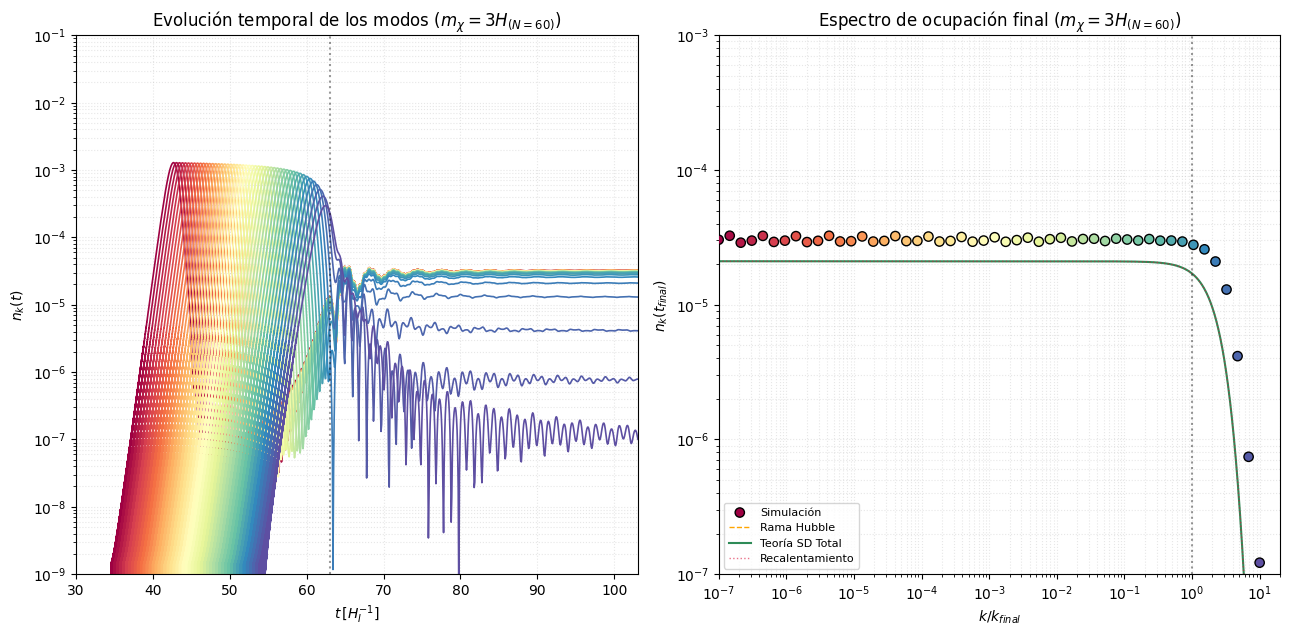

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, brentq, minimize
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CONFIGURACIÓN
# ============================================================
M_planck, H_inflacion = 1.0, 1.0 #normalización de rigor
alpha = 1.0          #parámetro principal de starobinsky
m_chi = 3.0 * H_inflacion  #masa de la partícula pesada
lambda_pot = (2 * H_inflacion)**2
N_objetivo = 60.0    #queremos los 60 e-folds de rigor
t_final_sim = 200.0  

#masa del inflatón y coeficiente del potencial según el alpha elegido
m_phi = (2.0 * H_inflacion) / np.sqrt(alpha) 
b_pot = np.sqrt(2 / (3 * alpha))

#ajustes de precisión para no perder la fase en los modos UV
objetivo_adiabatico = 1e-4
tol_rel, tol_abs = 1e-11, 1e-13

# ============================================================
# 2. DINÁMICA DE FONDO Y CALIBRACIÓN DE E-FOLDS
# ============================================================
def potencial_V(phi): 
    return 0.75 * lambda_pot * (1 - np.exp(-b_pot * phi))**2

def derivada_V(phi): 
    return 1.5 * b_pot * lambda_pot * (1 - np.exp(-b_pot * phi)) * np.exp(-b_pot * phi)

def ecuaciones_fondo(t, y):
    phi, phi_punto, log_a = y
    H = np.sqrt((0.5 * phi_punto**2 + potencial_V(phi)) / 3.0)
    return [phi_punto, -3 * H * phi_punto - derivada_V(phi), H]

def cuenta_efolds(p0):
    #simulación para contar cuánta inflación genera una phi0 dada
    sol_bg = solve_ivp(ecuaciones_fondo, (0, 10000), [p0, 0, 0], rtol=1e-8)
    H = np.sqrt((0.5 * sol_bg.y[1]**2 + potencial_V(sol_bg.y[0])) / 3.0)
    epsilon = (sol_bg.y[1]**2) / (2 * H**2)
    idx_final = np.where(epsilon >= 1.0)[0]
    return sol_bg.y[2][idx_final[0]] if len(idx_final) > 0 else 0

print(f"--- Calibrando fondo para alpha={alpha} y N={N_objetivo} ---")

#--- buscador dinámico de rango para generalizar cualquier alpha ---
def encontrar_bracket(objetivo):
    #estimación basada en la analítica de starobinsky
    phi_guia = (1/b_pot) * np.log(4*objetivo/(3*alpha))
    a, b = phi_guia * 0.5, phi_guia * 1.5
    while (cuenta_efolds(a) - objetivo) > 0 and a > 0.1:
        a /= 1.2
    while (cuenta_efolds(b) - objetivo) < 0 and b < 50:
        b *= 1.2
    return a, b

p_min, p_max = encontrar_bracket(N_objetivo)
phi0_exacto = brentq(lambda p: cuenta_efolds(p) - N_objetivo, p_min, p_max)

#integración final del fondo con la phi0 encontrada
sol_fondo = solve_ivp(ecuaciones_fondo, (0, 500), [phi0_exacto, 0, 0], 
                      t_eval=np.linspace(0, 500, 20000), rtol=tol_rel, atol=tol_abs)

t_fnd, a_fnd_val = sol_fondo.t, np.exp(sol_fondo.y[2])
H_fnd_val = np.sqrt((0.5 * sol_fondo.y[1]**2 + potencial_V(sol_fondo.y[0])) / 3.0)
H_punto_fnd_val = - (sol_fondo.y[1]**2) / 2.0

#localización exacta del fin de inflación
idx_final_inflacion = np.argmax((sol_fondo.y[1]**2 / (2 * H_fnd_val**2)) > 1.0)
t_final_infl = t_fnd[idx_final_inflacion]
k_final_infl = a_fnd_val[idx_final_inflacion] * H_fnd_val[idx_final_inflacion]

#interpoladores (motor para el cálculo de modos)
interp_a = interp1d(t_fnd, a_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H = interp1d(t_fnd, H_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H_punto = interp1d(t_fnd, H_punto_fnd_val, kind='cubic', fill_value="extrapolate")
H_final = H_fnd_val[idx_final_inflacion]
a_final = a_fnd_val[idx_final_inflacion]

print(f"Calibración exitosa: phi0 = {phi0_exacto:.4f} | t_final = {t_final_infl:.2f}")

#clave para las semillas analíticas: tiempo de cruce de horizonte
aH_fnd = a_fnd_val * H_fnd_val
interp_tiempo_cruce = interp1d(np.log(aH_fnd), t_fnd, kind='linear', fill_value="extrapolate")

# ============================================================
# 3. INTEGRACIÓN NUMÉRICA DE MODOS Y CONTROL DE CALIDAD
# ============================================================
def omega2_numerico(t, k):
    #frecuencia efectiva usando el fondo calibrado de starobinsky
    return k**2/interp_a(t)**2 + m_chi**2 - 2.25*interp_H(t)**2 - 1.5*interp_H_punto(t)

def calc_adiabaticidad(t, k):
    w2 = np.maximum(omega2_numerico(t, k), 1e-30)
    w = np.sqrt(w2)
    dt = 1e-4
    w_der = (np.sqrt(np.maximum(omega2_numerico(t+dt, k), 1e-30)) - 
             np.sqrt(np.maximum(omega2_numerico(t-dt, k), 1e-30))) / (2*dt)
    return np.abs(w_der / w2)

#malla de momentos k
k_lista = np.logspace(-7, 1, 50) * k_final_infl
#k_lista = k_lista[[2]]
nk_final_lista, lista_evolucion_nk, lista_tiempos, wr_err_lista = [], [], [], []

print(f"--- Integrando Starobinsky (alpha={alpha}, Adiabacidad={objetivo_adiabatico:.1e}) ---")
print(f"{'Modo':<5} | {'k/k_final':<10} | {'t_inicio':<12} | {'nk Final':<12} | {'Precisión(Wr)':<14} | {'Estado'}")
print("-" * 85)

for i, k in enumerate(k_lista):
    try: 
        t_ini = brentq(lambda t: calc_adiabaticidad(t, k) - objetivo_adiabatico, 0.1, t_final_infl - 2.0)
    except: 
        t_ini = 10.0 
    
    t_inicio_modo = t_ini

    #c.i. WKB (orden 1)
    w0 = np.sqrt(np.maximum(omega2_numerico(t_inicio_modo, k), 1e-30))
    X0 = 1.0 / np.sqrt(2.0 * w0)
    deps = 1e-5
    w_der0 = (np.sqrt(np.maximum(omega2_numerico(t_inicio_modo+deps, k), 1e-30)) - 
              np.sqrt(np.maximum(omega2_numerico(t_inicio_modo-deps, k), 1e-30))) / (2*deps)
    X_der0 = (-w_der0 / (4.0 * w0) - 1j * w0) * X0
    
    #integración con DOP853
    sol = solve_ivp(lambda t, y: [y[2], y[3], -omega2_numerico(t, k)*y[0], -omega2_numerico(t, k)*y[1]], 
                    (t_inicio_modo, t_final_sim), [X0.real, X0.imag, X_der0.real, X_der0.imag], 
                    method='DOP853', rtol=tol_rel, atol=tol_abs)
    
    #cálculo del wronskiano
    X_n = sol.y[0] + 1j*sol.y[1]
    Xd_n = sol.y[2] + 1j*sol.y[3]
    wr_err = np.max(np.abs(X_n * np.conj(Xd_n) - np.conj(X_n) * Xd_n - 1j))
    
    #cálculo de nk asintótico
    w_eval = np.sqrt(np.maximum(omega2_numerico(sol.t, k), 1e-30))
    nk_evol = (np.abs(Xd_n)**2 + w_eval**2 * np.abs(X_n)**2) / (2.0 * w_eval) - 0.5
    
    #media del tramo final para evitar oscilaciones
    num_puntos = len(nk_evol)
    diez_por_ciento = max(1, int(num_puntos * 0.01))
    nk_final_val = np.mean(nk_evol[-diez_por_ciento:]).real

    #--- lógica de discriminación ---
    if nk_final_val < wr_err:
        display_nk = "Bajo Ruido"
        nk_to_save = np.nan 
        status = "IMPRECISO (DESCARTADO)"
    else:
        display_nk = f"{nk_final_val:.2e}"
        nk_to_save = nk_final_val
        status = "PRECISO"

    nk_final_lista.append(nk_to_save)
    wr_err_lista.append(wr_err)
    lista_evolucion_nk.append(nk_evol.real)
    lista_tiempos.append(sol.t)

    #print informativo perfectamente alineado
    print(f"{i+1:<5d} | {k/k_final_infl:<10.2e} | {t_inicio_modo:<12.2f} | {display_nk:<12} | {wr_err:<14.1e} | {status}")

    #guardado dinámico
    np.savez(f"datos_starobinsky_alpha{alpha}_m_chi{m_chi}.npz", 
             k_ratio=k_lista[:i+1]/k_final_infl, 
             nk_final=nk_final_lista, 
             wr_errors=wr_err_lista,
             times=np.array(lista_tiempos, dtype=object), 
             nk_evolutions=np.array(lista_evolucion_nk, dtype=object))

# ============================================================
# 4. VALIDACIÓN ANALÍTICA (Steepest Descent)
# ============================================================
def omega2_compleja(t_c, k_v):
    tr, ti = t_c.real, t_c.imag
    ar, hr, hdr = interp_a(tr), interp_H(tr), interp_H_punto(tr)
    a2_complejo = (ar**2) * cmath.exp(2j * hr * ti)
    return k_v**2 / a2_complejo + m_chi**2 - 2.25 * hr**2 - 1.5 * hdr

def rama_hubble_analitica(ki, polo_previo):
    #semilla según tiempo de cruce
    try: t_semilla = min(float(interp_tiempo_cruce(np.log(ki))), t_final_infl - 0.1)
    except: t_semilla = t_final_infl - 5.0
    
    res = minimize(lambda x: np.abs(omega2_compleja(x[0] + 1j * x[1], ki)), 
                    [t_semilla, 1.95 if polo_previo is None else polo_previo.imag], 
                    method='Nelder-Mead', tol=1e-15)
    tp = res.x[0] + 1j * res.x[1]
    
    if res.fun < 1e-11 and tp.real < t_final_infl + 2.0:
        ys = np.linspace(0, abs(tp.imag), 3000)
        ws = [cmath.sqrt(omega2_compleja(tp.real + 1j * y, ki)) for y in ys]
        for j in range(1, len(ws)):
            if np.real(ws[j] * np.conj(ws[j-1])) < 0: ws[j] = -ws[j]
        integral = np.trapezoid(ws, ys)
        return (np.pi**2 / 9.0) * np.exp(-4.0 * np.abs(integral.real)), tp
    return np.nan, polo_previo

def rama_recalentamiento_analitica(ki, z0):
    #potencial oscilatorio tras inflación
    w2_recal = lambda t_c: (ki**2 / a_final**2) + m_chi**2 - (1.125 * H_final**2 * cmath.cos(2.0 * m_phi * t_c))
    tp = 1j * (1.0 / (2.0 * m_phi)) * np.log((16.0/9.0) * (m_chi**2 / H_final**2))
    ys = np.linspace(0, abs(tp.imag), 2000)
    ws = np.array([cmath.sqrt(w2_recal(tp.real + 1j*y)) for y in ys])
    integral = np.trapezoid(ws.real, ys)
    return (np.pi**2 / 9.0) * np.exp(-4.0 * integral), tp

#ejecución de la validación
k_ir = np.logspace(-7, 0.000001, 100)   # Zona de salida de horizonte
k_uv = np.linspace(0.01, 15.0, 500)
k_ratios_analitico = np.sort(np.unique(np.concatenate([k_ir, k_uv])))
nk_hubble, nk_preheat = [], []
polo_h, polo_p = None, [0.0, (1.0 / (2.0 * m_phi)) * np.log((16/9* m_chi**2 / H_final**2))]

print("\n--- Calculando curvas de Steepest Descent ---")
for kr in k_ratios_analitico:
    ki = kr * k_final_infl
    val_h, polo_h = rama_hubble_analitica(ki, polo_h)
    nk_hubble.append(val_h)
    val_p, tp_p_comp = rama_recalentamiento_analitica(ki, [polo_p[0], polo_p[1]])
    polo_p = [tp_p_comp.real, tp_p_comp.imag]
    nk_preheat.append(val_p)

#unión de ramas
mask_h = (~np.isnan(nk_hubble)) & (np.array(nk_hubble) > 0)
interp_h = interp1d(np.log10(k_ratios_analitico[mask_h]), np.log10(np.array(nk_hubble)[mask_h]), 
                    kind='linear', fill_value="extrapolate")
hubble_finalizado = 10**interp_h(np.log10(k_ratios_analitico))
hubble_finalizado[k_ratios_analitico > k_ratios_analitico[mask_h][-1] * 1.2] = np.nan
nk_total_teoria = np.nan_to_num(hubble_finalizado) + np.array(nk_preheat)

# ============================================================
# 5. PANEL DE RESULTADOS FINAL 
# ============================================================
colores_spec = cm.Spectral(np.linspace(0, 1, len(nk_final_lista)))

fig = plt.figure(figsize=(13, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0, 0])    #arriba izq: evolución
ax2 = fig.add_subplot(gs[0, 1])    #arriba der: espectro n_k

#--- panel 1: evolución temporal ---
for i in range(len(nk_final_lista)):
    ax1.plot(lista_tiempos[i], np.maximum(lista_evolucion_nk[i], 1e-40), color=colores_spec[i], lw=1.2)
ax1.set_yscale('log')
ax1.set_xlim(30, t_final_infl + 40)
ax1.axvline(t_final_infl, color='black', ls=':', alpha=0.4, label='Fin Inflación')
ax1.set_xlim(30, t_final_infl + 40)
ax1.set_ylim(1e-9, 1e-1)
ax1.set_xlabel(r'$t\,[H_I^{-1}]$')
ax1.set_ylabel(r'$n_k(t)$')
ax1.set_title(r'Evolución temporal de los modos ($m_\chi = 3 H_{(N=60)}$)')
ax1.grid(True, which='both', ls=':', alpha=0.3)

#--- panel 2: espectro estándar ---
ax2.scatter(k_lista/k_final_infl, np.maximum(nk_final_lista, 1e-40), 
               c=colores_spec, edgecolor='black', s=45, zorder=5, label='Simulación')
ax2.loglog(k_ratios_analitico, hubble_finalizado, color='orange', ls='--', lw=1.0, label='Rama Hubble')
ax2.loglog(k_ratios_analitico, nk_total_teoria, color='seagreen', ls='-', lw=1.5, label='Teoría SD Total')
ax2.loglog(k_ratios_analitico, nk_preheat, color='crimson', ls=':', lw=1.0, alpha=0.6, label='Recalentamiento')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(1e-7, 1e-3)
ax2.set_xlim(1e-7, 20)
ax2.axvline(1.0, color='black', ls=':', alpha=0.4)
ax2.set_xlabel(r'$k/k_{final}$')
ax2.set_ylabel(r'$n_k(t_{final})$')
ax2.set_title(r'Espectro de ocupación final ($m_\chi = 3 H_{(N=60)}$)')
ax2.legend(fontsize=8, loc='lower left', frameon=True)
ax2.grid(True, which='both', ls=':', alpha=0.3)


plt.tight_layout()
bbox_ax1 = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)
bbox_ax2 = ax2.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# Guardar de forma independiente cada panel recortado
plt.savefig(f"Fig6_Evolucion_Modos_Starobinsky_alpha{alpha}_m{m_chi}H_I.pdf", bbox_inches=bbox_ax1)
plt.savefig(f"Fig7_Espectro_Final_Starobinsky_alpha{alpha}_m{m_chi}H_I.pdf", bbox_inches=bbox_ax2)

print(f"Figuras guardadas: 'Fig6_Evolucion_Modos_Starobinsky_alpha{alpha}_m{m_chi}H_I.pdf' y 'Fig7_Espectro_Final_Starobinsky_alpha{alpha}_m{mc_hi}H_I.pdf'")
plt.show()
plt.show()

--- Calibrando fondo para alpha=1.0 y N=60.0 ---
Calibración exitosa: phi0 = 5.4160 | t_final = 63.03
Calculando rama de Steepest Descent (Paseo del Polo)...


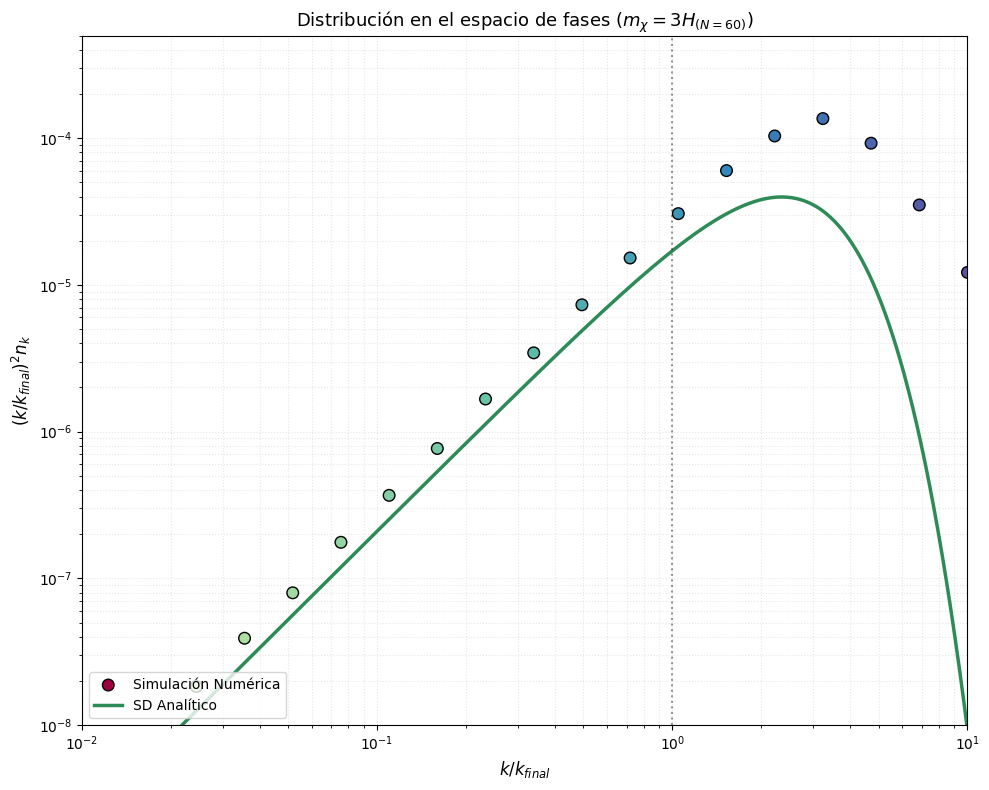


--- RESULTADO DE LA PRODUCCIÓN TOTAL ---
n_chi / k_final^3 = 3.879754e-05 m_chi/H_(N=60)
Gráfico exportado correctamente como: 'Fig8_Espacio_Fases_Starobinsky_alpha1.0_mchi3.0.pdf'


<Figure size 640x480 with 0 Axes>

In [63]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, brentq, minimize
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CONFIGURACIÓN
# ============================================================
M_planck, H_inflacion = 1.0, 1.0 #normalización de rigor
alpha = 1.0          #parámetro principal de starobinsky
m_chi = 3.0 * H_inflacion  #masa de la partícula pesada
lambda_pot = (2 * H_inflacion)**2
N_objetivo = 60.0    #queremos los 60 e-folds de rigor
t_final_sim = 150.0  

#masa del inflatón y coeficiente del potencial según el alpha elegido
m_phi = (2.0 * H_inflacion) / np.sqrt(alpha) 
b_pot = np.sqrt(2 / (3 * alpha))

#ajustes de precisión para no perder la fase en los modos UV
objetivo_adiabatico = 1e-4
tol_rel, tol_abs = 1e-11, 1e-13

# ============================================================
# 2. DINÁMICA DE FONDO Y CALIBRACIÓN DE E-FOLDS
# ============================================================
def potencial_V(phi): 
    return 0.75 * lambda_pot * (1 - np.exp(-b_pot * phi))**2

def derivada_V(phi): 
    return 1.5 * b_pot * lambda_pot * (1 - np.exp(-b_pot * phi)) * np.exp(-b_pot * phi)

def ecuaciones_fondo(t, y):
    phi, phi_punto, log_a = y
    H = np.sqrt((0.5 * phi_punto**2 + potencial_V(phi)) / 3.0)
    return [phi_punto, -3 * H * phi_punto - derivada_V(phi), H]

def cuenta_efolds(p0):
    #simulación para contar cuánta inflación genera una phi0 dada
    sol_bg = solve_ivp(ecuaciones_fondo, (0, 10000), [p0, 0, 0], rtol=1e-8)
    H = np.sqrt((0.5 * sol_bg.y[1]**2 + potencial_V(sol_bg.y[0])) / 3.0)
    epsilon = (sol_bg.y[1]**2) / (2 * H**2)
    idx_final = np.where(epsilon >= 1.0)[0]
    return sol_bg.y[2][idx_final[0]] if len(idx_final) > 0 else 0

print(f"--- Calibrando fondo para alpha={alpha} y N={N_objetivo} ---")

#--- buscador dinámico de rango para generalizar cualquier alpha ---
def encontrar_bracket(objetivo):
    #estimación basada en la analítica de starobinsky
    phi_guia = (1/b_pot) * np.log(4*objetivo/(3*alpha))
    a, b = phi_guia * 0.5, phi_guia * 1.5
    while (cuenta_efolds(a) - objetivo) > 0 and a > 0.1:
        a /= 1.2
    while (cuenta_efolds(b) - objetivo) < 0 and b < 50:
        b *= 1.2
    return a, b

p_min, p_max = encontrar_bracket(N_objetivo)
phi0_exacto = brentq(lambda p: cuenta_efolds(p) - N_objetivo, p_min, p_max)

#integración final del fondo con la phi0 encontrada
sol_fondo = solve_ivp(ecuaciones_fondo, (0, 500), [phi0_exacto, 0, 0], 
                      t_eval=np.linspace(0, 500, 20000), rtol=tol_rel, atol=tol_abs)

t_fnd, a_fnd_val = sol_fondo.t, np.exp(sol_fondo.y[2])
H_fnd_val = np.sqrt((0.5 * sol_fondo.y[1]**2 + potencial_V(sol_fondo.y[0])) / 3.0)
H_punto_fnd_val = - (sol_fondo.y[1]**2) / 2.0

#localización exacta del fin de inflación
idx_final_inflacion = np.argmax((sol_fondo.y[1]**2 / (2 * H_fnd_val**2)) > 1.0)
t_final_infl = t_fnd[idx_final_inflacion]
k_final_infl = a_fnd_val[idx_final_inflacion] * H_fnd_val[idx_final_inflacion]

#interpoladores
interp_a = interp1d(t_fnd, a_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H = interp1d(t_fnd, H_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H_punto = interp1d(t_fnd, H_punto_fnd_val, kind='cubic', fill_value="extrapolate")
H_final = H_fnd_val[idx_final_inflacion]
a_final = a_fnd_val[idx_final_inflacion]

print(f"Calibración exitosa: phi0 = {phi0_exacto:.4f} | t_final = {t_final_infl:.2f}")

#clave para las semillas analíticas: tiempo de cruce de horizonte
aH_fnd = a_fnd_val * H_fnd_val
interp_tiempo_cruce = interp1d(np.log(aH_fnd), t_fnd, kind='linear', fill_value="extrapolate")

# ============================================================
# 3. RECOGIDA DE MODOS NUMÉRICOS ANTERIORES
# ============================================================
#cargamos los datos generados en la simulación previa
datos = np.load(f"datos_starobinsky_alpha{alpha}_m_chi{m_chi}.npz", allow_pickle=True)
k_lista = datos['k_ratio'] * k_final_infl
nk_final_lista = datos['nk_final']

# ============================================================
# 4. VALIDACIÓN ANALÍTICA (Steepest Descent)
# ============================================================
def omega2_compleja(t_c, k_v):
    tr, ti = t_c.real, t_c.imag
    ar, hr, hdr = interp_a(tr), interp_H(tr), interp_H_punto(tr)
    a2_complejo = (ar**2) * cmath.exp(2j * hr * ti)
    return k_v**2 / a2_complejo + m_chi**2 - 2.25 * hr**2 - 1.5 * hdr

def rama_hubble_analitica(ki, polo_previo):
    #semilla según tiempo de cruce
    try: t_semilla = min(float(interp_tiempo_cruce(np.log(ki))), t_final_infl - 0.1)
    except: t_semilla = t_final_infl - 5.0
    
    res = minimize(lambda x: np.abs(omega2_compleja(x[0] + 1j * x[1], ki)), 
                    [t_semilla, 1.95 if polo_previo is None else polo_previo.imag], 
                    method='Nelder-Mead', tol=1e-15)
    tp = res.x[0] + 1j * res.x[1]
    
    if res.fun < 1e-11 and tp.real < t_final_infl + 2.0:
        ys = np.linspace(0, abs(tp.imag), 3000)
        ws = [cmath.sqrt(omega2_compleja(tp.real + 1j * y, ki)) for y in ys]
        for j in range(1, len(ws)):
            if np.real(ws[j] * np.conj(ws[j-1])) < 0: ws[j] = -ws[j]
        integral = np.trapezoid(ws, ys)
        return (np.pi**2 / 9.0) * np.exp(-4.0 * np.abs(integral.real)), tp
    return np.nan, polo_previo

def rama_recalentamiento_analitica(ki, z0):
    #potencial oscilatorio tras inflación
    w2_recal = lambda t_c: (ki**2 / a_final**2) + m_chi**2 - (1.125 * H_final**2 * cmath.cos(2.0 * m_phi * t_c))
    tp = 1j * (1.0 / (2.0 * m_phi)) * np.log((16.0/9.0) * (m_chi**2 / H_final**2))
    ys = np.linspace(0, abs(tp.imag), 2000)
    ws = np.array([cmath.sqrt(w2_recal(tp.real + 1j*y)) for y in ys])
    integral = np.trapezoid(ws.real, ys)
    return (np.pi**2 / 9.0) * np.exp(-4.0 * integral), tp

#ejecución de la validación
k_ir = np.logspace(-7, 0.000001, 100)   # Zona de salida de horizonte
k_uv = np.linspace(0.01, 15.0, 500)   # Zona de recalentamiento (malla densa)
k_ratios_analitico = np.sort(np.unique(np.concatenate([k_ir, k_uv])))
nk_hubble, nk_preheat = [], []
polo_h, polo_p = None, [0.0, (1.0 / (2.0 * m_phi)) * np.log((16/9 * m_chi**2 / H_final**2))]

print("Calculando rama de Steepest Descent (Paseo del Polo)...")
for kr in k_ratios_analitico:
    ki = kr * k_final_infl
    val_h, polo_h = rama_hubble_analitica(ki, polo_h)
    nk_hubble.append(val_h)
    val_p, tp_p_comp = rama_recalentamiento_analitica(ki, [polo_p[0], polo_p[1]])
    polo_p = [tp_p_comp.real, tp_p_comp.imag]
    nk_preheat.append(val_p)

#unión de ramas
mask_h = (~np.isnan(nk_hubble)) & (np.array(nk_hubble) > 0)
interp_h = interp1d(np.log10(k_ratios_analitico[mask_h]), np.log10(np.array(nk_hubble)[mask_h]), 
                    kind='linear', fill_value="extrapolate")
hubble_finalizado = 10**interp_h(np.log10(k_ratios_analitico))
hubble_finalizado[k_ratios_analitico > k_ratios_analitico[mask_h][-1] * 1.2] = np.nan

recalentamiento_filtrado = np.array(nk_preheat)
nk_total_teoria = np.nan_to_num(hubble_finalizado) + recalentamiento_filtrado
# ============================================================
# 5. PLOT
# ============================================================
colores_spec = cm.Spectral(np.linspace(0, 1, len(nk_final_lista)))
fig, ax = plt.subplots(figsize=(10, 8))

if len(k_lista) > 0:
    #filtramos nans para el scatter
    mask_num = ~np.isnan(nk_final_lista)
    y_num_lin = (k_lista[mask_num]/k_final_infl)**2 * np.array(nk_final_lista)[mask_num]
    ax.scatter(k_lista[mask_num]/k_final_infl, y_num_lin, 
                  c=cm.Spectral(np.linspace(0, 1, len(y_num_lin))), 
                  edgecolor='black', s=70, zorder=5, label='Simulación Numérica')

#curva teórica sd
y_teoria_lin = k_ratios_analitico**2 * nk_total_teoria
ax.loglog(k_ratios_analitico, y_teoria_lin, color='seagreen', ls='-', lw=2.5, label=r'SD Analítico')

#ajustes estéticos idénticos a los originales
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(1.0, color='black', ls=':', alpha=0.4)
ax.set_xlabel(r'$k/k_{final}$', fontsize=12)
ax.set_ylabel(r'$(k/k_{final})^2 n_k$', fontsize=12)
ax.set_ylim(1e-8, 5e-4)
ax.set_xlim(1e-2, 10)
ax.set_title(r'Distribución en el espacio de fases ($m_\chi = 3 H_{(N=60)}$)', fontsize=13)
ax.grid(True, which="both", ls=':', alpha=0.3)
ax.legend(fontsize=10, loc='lower left', frameon=True)

plt.tight_layout()
plt.show()

# ============================================================
# 6. VALOR DE LA INTEGRAL EN EL ESPACIO DE FASES
# ============================================================
integral_fases = np.trapezoid(y_teoria_lin, x=k_ratios_analitico)
n_total_normalizada = (1.0 / (2 * np.pi**2)) * integral_fases

print(f"\n--- RESULTADO DE LA PRODUCCIÓN TOTAL ---")
print(f"n_chi / k_final^3 = {n_total_normalizada:.6e} m_chi/H_(N=60)")
bbox_ax = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# Nombre dinámico que incluye tanto alpha como m_chi
nombre_archivo = f"Fig8_Espacio_Fases_Starobinsky_alpha{alpha}_mchi{m_chi}.pdf"
plt.savefig(nombre_archivo, bbox_inches=bbox_ax)

print(f"Gráfico exportado correctamente como: '{nombre_archivo}'")
plt.show()

## $\alpha = 5$

--- Calibrando fondo para alpha=5.0 y N=60.0 ---
Calibración exitosa: phi0 = 8.1510 | t_final = 70.40
--- Integrando Starobinsky (alpha=5.0, Adiabacidad=1.0e-04) ---
Modo  | k/k_final  | t_inicio     | nk Final     | Precisión(Wr)  | Estado
-------------------------------------------------------------------------------------
1     | 1.00e-07   | 36.04        | 1.83e-05     | 1.6e-09        | PRECISO
2     | 1.46e-07   | 36.46        | 1.61e-05     | 1.6e-09        | PRECISO
3     | 2.12e-07   | 36.88        | 1.48e-05     | 1.6e-09        | PRECISO
4     | 3.09e-07   | 37.30        | 1.51e-05     | 1.6e-09        | PRECISO
5     | 4.50e-07   | 37.72        | 1.53e-05     | 1.6e-09        | PRECISO
6     | 6.55e-07   | 38.14        | 1.43e-05     | 1.6e-09        | PRECISO
7     | 9.54e-07   | 38.56        | 1.25e-05     | 1.6e-09        | PRECISO
8     | 1.39e-06   | 38.98        | 1.15e-05     | 1.6e-09        | PRECISO
9     | 2.02e-06   | 39.40        | 1.19e-05     | 1.6e-09       

NameError: name 'mchi' is not defined

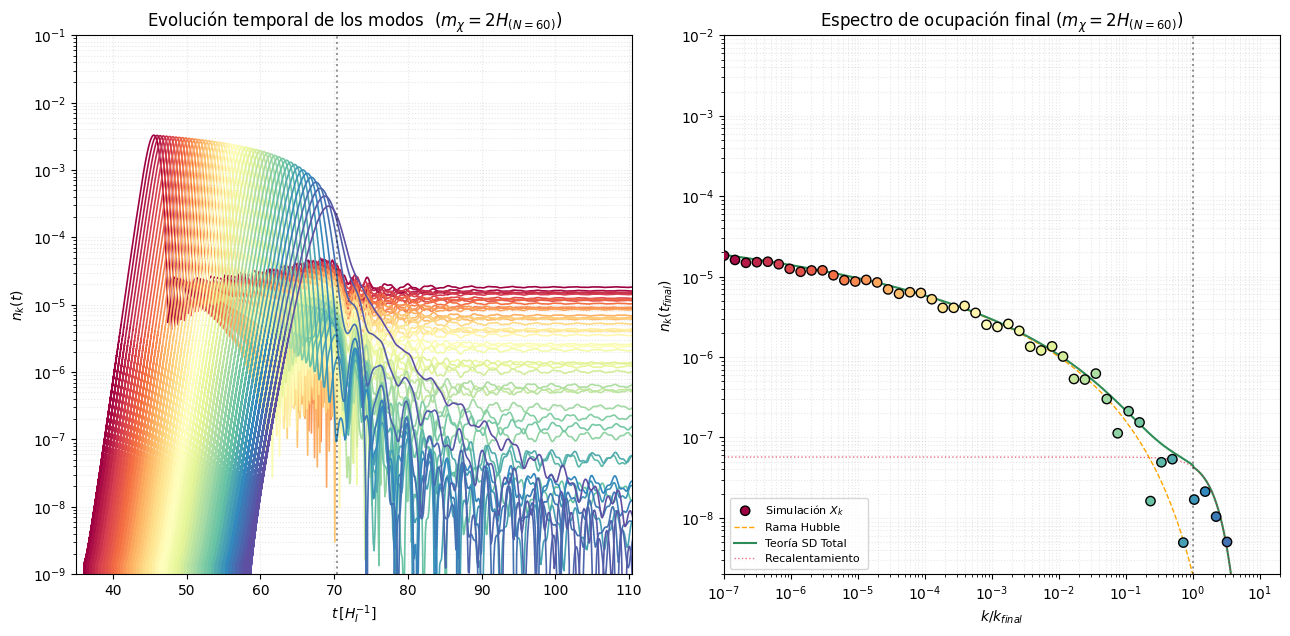

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, brentq, minimize
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import cmath
import os

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CONFIGURACIÓN
# ============================================================
M_planck, H_inflacion = 1.0, 1.0 #normalización de rigor
alpha = 5.0          #parámetro principal de starobinsky
m_chi = 2.0 * H_inflacion  #masa de la partícula pesada
lambda_pot = (2 * H_inflacion)**2
N_objetivo = 60.0    #queremos los 60 e-folds de rigor
t_final_sim = 200.0  

#masa del inflatón y coeficiente del potencial según el alpha elegido
m_phi = (2.0 * H_inflacion) / np.sqrt(alpha) 
b_pot = np.sqrt(2 / (3 * alpha))

#ajustes de precisión para no perder la fase en los modos UV
objetivo_adiabatico = 1e-4
tol_rel, tol_abs = 1e-11, 1e-13

# ============================================================
# 2. DINÁMICA DE FONDO Y CALIBRACIÓN DE E-FOLDS
# ============================================================
def potencial_V(phi): 
    return 0.75 * lambda_pot * (1 - np.exp(-b_pot * phi))**2

def derivada_V(phi): 
    return 1.5 * b_pot * lambda_pot * (1 - np.exp(-b_pot * phi)) * np.exp(-b_pot * phi)

def ecuaciones_fondo(t, y):
    phi, phi_punto, log_a = y
    H = np.sqrt((0.5 * phi_punto**2 + potencial_V(phi)) / 3.0)
    return [phi_punto, -3 * H * phi_punto - derivada_V(phi), H]

def cuenta_efolds(p0):
    #simulación para contar cuánta inflación genera una phi0 dada
    sol_bg = solve_ivp(ecuaciones_fondo, (0, 10000), [p0, 0, 0], rtol=1e-8)
    H = np.sqrt((0.5 * sol_bg.y[1]**2 + potencial_V(sol_bg.y[0])) / 3.0)
    epsilon = (sol_bg.y[1]**2) / (2 * H**2)
    idx_final = np.where(epsilon >= 1.0)[0]
    return sol_bg.y[2][idx_final[0]] if len(idx_final) > 0 else 0

print(f"--- Calibrando fondo para alpha={alpha} y N={N_objetivo} ---")

#--- buscador dinámico de rango para generalizar cualquier alpha ---
def encontrar_bracket(objetivo):
    #estimación basada en la analítica de starobinsky
    phi_guia = (1/b_pot) * np.log(4*objetivo/(3*alpha))
    a, b = phi_guia * 0.5, phi_guia * 1.5
    while (cuenta_efolds(a) - objetivo) > 0 and a > 0.1:
        a /= 1.2
    while (cuenta_efolds(b) - objetivo) < 0 and b < 50:
        b *= 1.2
    return a, b

p_min, p_max = encontrar_bracket(N_objetivo)
phi0_exacto = brentq(lambda p: cuenta_efolds(p) - N_objetivo, p_min, p_max)

#integración final del fondo con la phi0 encontrada
sol_fondo = solve_ivp(ecuaciones_fondo, (0, 500), [phi0_exacto, 0, 0], 
                      t_eval=np.linspace(0, 500, 20000), rtol=tol_rel, atol=tol_abs)

t_fnd, a_fnd_val = sol_fondo.t, np.exp(sol_fondo.y[2])
H_fnd_val = np.sqrt((0.5 * sol_fondo.y[1]**2 + potencial_V(sol_fondo.y[0])) / 3.0)
H_punto_fnd_val = - (sol_fondo.y[1]**2) / 2.0

#localización exacta del fin de inflación
idx_final_inflacion = np.argmax((sol_fondo.y[1]**2 / (2 * H_fnd_val**2)) > 1.0)
t_final_infl = t_fnd[idx_final_inflacion]
k_final_infl = a_fnd_val[idx_final_inflacion] * H_fnd_val[idx_final_inflacion]

#interpoladores (motor para el cálculo de modos)
interp_a = interp1d(t_fnd, a_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H = interp1d(t_fnd, H_fnd_val, kind='cubic', fill_value="extrapolate")
interp_H_punto = interp1d(t_fnd, H_punto_fnd_val, kind='cubic', fill_value="extrapolate")
H_final = H_fnd_val[idx_final_inflacion]
a_final = a_fnd_val[idx_final_inflacion]

print(f"Calibración exitosa: phi0 = {phi0_exacto:.4f} | t_final = {t_final_infl:.2f}")

#clave para las semillas analíticas: tiempo de cruce de horizonte
aH_fnd = a_fnd_val * H_fnd_val
interp_tiempo_cruce = interp1d(np.log(aH_fnd), t_fnd, kind='linear', fill_value="extrapolate")

# ============================================================
# 3. INTEGRACIÓN NUMÉRICA DE MODOS Y CONTROL DE CALIDAD
# ============================================================
def omega2_numerico(t, k):
    #frecuencia efectiva usando el fondo calibrado de starobinsky
    return k**2/interp_a(t)**2 + m_chi**2 - 2.25*interp_H(t)**2 - 1.5*interp_H_punto(t)

def calc_adiabaticidad(t, k):
    w2 = np.maximum(omega2_numerico(t, k), 1e-30)
    w = np.sqrt(w2)
    dt = 1e-4
    w_der = (np.sqrt(np.maximum(omega2_numerico(t+dt, k), 1e-30)) - 
             np.sqrt(np.maximum(omega2_numerico(t-dt, k), 1e-30))) / (2*dt)
    return np.abs(w_der / w2)

#malla de momentos k
k_lista = np.logspace(-7, 1, 50) * k_final_infl
#k_lista = k_lista[[4,33]] #comprobaciones
nk_final_lista, lista_evolucion_nk, lista_tiempos, wr_err_lista = [], [], [], []

print(f"--- Integrando Starobinsky (alpha={alpha}, Adiabacidad={objetivo_adiabatico:.1e}) ---")
print(f"{'Modo':<5} | {'k/k_final':<10} | {'t_inicio':<12} | {'nk Final':<12} | {'Precisión(Wr)':<14} | {'Estado'}")
print("-" * 85)

for i, k in enumerate(k_lista):
    try: 
        t_ini = brentq(lambda t: calc_adiabaticidad(t, k) - objetivo_adiabatico, 0.1, t_final_infl - 2.0)
    except: 
        t_ini = 10.0 
    
    t_inicio_modo = t_ini

    #c.i. WKB (orden 1)
    w0 = np.sqrt(np.maximum(omega2_numerico(t_inicio_modo, k), 1e-30))
    X0 = 1.0 / np.sqrt(2.0 * w0)
    deps = 1e-5
    w_der0 = (np.sqrt(np.maximum(omega2_numerico(t_inicio_modo+deps, k), 1e-30)) - 
              np.sqrt(np.maximum(omega2_numerico(t_inicio_modo-deps, k), 1e-30))) / (2*deps)
    X_der0 = (-w_der0 / (4.0 * w0) - 1j * w0) * X0
    
    #integración con DOP853
    sol = solve_ivp(lambda t, y: [y[2], y[3], -omega2_numerico(t, k)*y[0], -omega2_numerico(t, k)*y[1]], 
                    (t_inicio_modo, t_final_sim), [X0.real, X0.imag, X_der0.real, X_der0.imag], 
                    method='DOP853', rtol=tol_rel, atol=tol_abs)
    
    #cálculo del wronskiano
    X_n = sol.y[0] + 1j*sol.y[1]
    Xd_n = sol.y[2] + 1j*sol.y[3]
    wr_err = np.max(np.abs(X_n * np.conj(Xd_n) - np.conj(X_n) * Xd_n - 1j))
    
    #cálculo de nk asintótico
    w_eval = np.sqrt(np.maximum(omega2_numerico(sol.t, k), 1e-30))
    nk_evol = (np.abs(Xd_n)**2 + w_eval**2 * np.abs(X_n)**2) / (2.0 * w_eval) - 0.5
    
    #media del tramo final para evitar oscilaciones
    num_puntos = len(nk_evol)
    diez_por_ciento = max(1, int(num_puntos * 0.01))
    nk_final_val = np.mean(nk_evol[-diez_por_ciento:]).real

    #--- lógica de discriminación ---
    if nk_final_val < wr_err:
        display_nk = "Bajo Ruido"
        nk_to_save = np.nan 
        status = "IMPRECISO (DESCARTADO)"
    else:
        display_nk = f"{nk_final_val:.2e}"
        nk_to_save = nk_final_val
        status = "PRECISO"

    nk_final_lista.append(nk_to_save)
    wr_err_lista.append(wr_err)
    lista_evolucion_nk.append(nk_evol.real)
    lista_tiempos.append(sol.t)

    #print informativo perfectamente alineado
    print(f"{i+1:<5} | {k/k_final_infl:<10.2e} | {t_inicio_modo:<12.2f} | {display_nk:<12} | {wr_err:<14.1e} | {status}")

    #guardado dinámico
    np.savez(f"datos_starobinsky_alpha{alpha}_m_chi{m_chi}.npz", 
             k_ratio=k_lista[:i+1]/k_final_infl, 
             nk_final=nk_final_lista, 
             wr_errors=wr_err_lista,
             times=np.array(lista_tiempos, dtype=object), 
             nk_evolutions=np.array(lista_evolucion_nk, dtype=object))

# ============================================================
# 4. VALIDACIÓN ANALÍTICA (Steepest Descent)
# ============================================================
def omega2_compleja(t_c, k_v):
    tr, ti = t_c.real, t_c.imag
    ar, hr, hdr = interp_a(tr), interp_H(tr), interp_H_punto(tr)
    a2_complejo = (ar**2) * cmath.exp(2j * hr * ti)
    return k_v**2 / a2_complejo + m_chi**2 - 2.25 * hr**2 - 1.5 * hdr

def rama_hubble_analitica(ki, polo_previo):
    #semilla según tiempo de cruce
    try: t_semilla = min(float(interp_tiempo_cruce(np.log(ki))), t_final_infl - 0.1)
    except: t_semilla = t_final_infl - 5.0
    
    res = minimize(lambda x: np.abs(omega2_compleja(x[0] + 1j * x[1], ki)), 
                    [t_semilla, 1.95 if polo_previo is None else polo_previo.imag], 
                    method='Nelder-Mead', tol=1e-15)
    tp = res.x[0] + 1j * res.x[1]
    
    if res.fun < 1e-11 and tp.real < t_final_infl + 2.0:
        ys = np.linspace(0, abs(tp.imag), 3000)
        ws = [cmath.sqrt(omega2_compleja(tp.real + 1j * y, ki)) for y in ys]
        for j in range(1, len(ws)):
            if np.real(ws[j] * np.conj(ws[j-1])) < 0: ws[j] = -ws[j]
        integral = np.trapezoid(ws, ys)
        return (np.pi**2 / 9.0) * np.exp(-4.0 * np.abs(integral.real)), tp
    return np.nan, polo_previo

def rama_recalentamiento_analitica(ki, z0):
    #potencial oscilatorio tras inflación
    w2_recal = lambda t_c: (ki**2 / a_final**2) + m_chi**2 - (1.125 * H_final**2 * cmath.cos(2.0 * m_phi * t_c))
    tp = 1j * (1.0 / (2.0 * m_phi)) * np.log((16.0/9.0) * (m_chi**2 / H_final**2))
    ys = np.linspace(0, abs(tp.imag), 2000)
    ws = np.array([cmath.sqrt(w2_recal(tp.real + 1j*y)) for y in ys])
    integral = np.trapezoid(ws.real, ys)
    return (np.pi**2 / 9.0) * np.exp(-4.0 * integral), tp

#ejecución de la validación
k_ir = np.logspace(-7, 0.000001, 100)   # Zona de salida de horizonte
k_uv = np.linspace(0.01, 15.0, 500)
k_ratios_analitico = np.sort(np.unique(np.concatenate([k_ir, k_uv])))
nk_hubble, nk_preheat = [], []
polo_h, polo_p = None, [0.0, (1.0 / (2.0 * m_phi)) * np.log((16/9* m_chi**2 / H_final**2))]

print("\n--- Calculando curvas de Steepest Descent ---")
for kr in k_ratios_analitico:
    ki = kr * k_final_infl
    val_h, polo_h = rama_hubble_analitica(ki, polo_h)
    nk_hubble.append(val_h)
    val_p, tp_p_comp = rama_recalentamiento_analitica(ki, [polo_p[0], polo_p[1]])
    polo_p = [tp_p_comp.real, tp_p_comp.imag]
    nk_preheat.append(val_p)

#unión de ramas
mask_h = (~np.isnan(nk_hubble)) & (np.array(nk_hubble) > 0)
interp_h = interp1d(np.log10(k_ratios_analitico[mask_h]), np.log10(np.array(nk_hubble)[mask_h]), 
                    kind='linear', fill_value="extrapolate")
hubble_finalizado = 10**interp_h(np.log10(k_ratios_analitico))
hubble_finalizado[k_ratios_analitico > k_ratios_analitico[mask_h][-1] * 1.2] = np.nan
nk_total_teoria = np.nan_to_num(hubble_finalizado) + np.array(nk_preheat)

# ============================================================
# 5. PANEL DE RESULTADOS FINAL (Disposición TFG)
# ============================================================
colores_spec = cm.Spectral(np.linspace(0, 1, len(nk_final_lista)))

fig = plt.figure(figsize=(13, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0, 0])    #arriba izq: evolución
ax2 = fig.add_subplot(gs[0, 1])    #arriba der: espectro n_k

#--- panel 1: evolución temporal ---
for i in range(len(nk_final_lista)):
    ax1.plot(lista_tiempos[i], np.maximum(lista_evolucion_nk[i], 1e-40), color=colores_spec[i], lw=1.2)
ax1.set_yscale('log')
ax1.set_xlim(35, t_final_infl + 40)
ax1.axvline(t_final_infl, color='black', ls=':', alpha=0.4, label='Fin Inflación')
ax1.set_xlim(35, t_final_infl + 40)
ax1.set_ylim(1e-9, 1e-1)
ax1.set_xlabel(r'$t\,[H_I^{-1}]$')
ax1.set_ylabel(r'$n_k(t)$')
ax1.set_title(r'Evolución temporal de los modos  ($m_\chi = 2 H_{(N=60)}$)')
ax1.grid(True, which='both', ls=':', alpha=0.3)

#--- panel 2: espectro estándar ---
ax2.scatter(k_lista/k_final_infl, np.maximum(nk_final_lista, 1e-40), 
               c=colores_spec, edgecolor='black', s=45, zorder=5, label=r'Simulación $X_k$')
ax2.loglog(k_ratios_analitico, hubble_finalizado, color='orange', ls='--', lw=1.0, label='Rama Hubble')
ax2.loglog(k_ratios_analitico, nk_total_teoria, color='seagreen', ls='-', lw=1.5, label='Teoría SD Total')
ax2.loglog(k_ratios_analitico, nk_preheat, color='crimson', ls=':', lw=1.0, alpha=0.6, label='Recalentamiento ')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(2e-9, 1e-2)
ax2.set_xlim(1e-7, 20)
ax2.axvline(1.0, color='black', ls=':', alpha=0.4)
ax2.set_xlabel(r'$k/k_{final}$')
ax2.set_ylabel(r'$n_k(t_{final})$')
ax2.set_title(r'Espectro de ocupación final ($m_\chi = 2 H_{(N=60)}$)')
ax2.legend(fontsize=8, loc='lower left', frameon=True)
ax2.grid(True, which='both', ls=':', alpha=0.3)


plt.tight_layout()
bbox_ax1 = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)
bbox_ax2 = ax2.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# Guardar de forma independiente cada panel recortado
plt.savefig(f"Fig6_Evolucion_Modos_Starobinsky_alpha{alpha}_m{m_chi}H_I.pdf", bbox_inches=bbox_ax1)
plt.savefig(f"Fig7_Espectro_Final_Starobinsky_alpha{alpha}_m{m_chi}H_I.pdf", bbox_inches=bbox_ax2)

print(f"Figuras guardadas: 'Fig6_Evolucion_Modos_Starobinsky_alpha{alpha}_m{m_chi}H_I.pdf' y 'Fig7_Espectro_Final_Starobinsky_alpha{alpha}_m{mchi}H_I.pdf'")
plt.show()



--- RESULTADO DE LA PRODUCCIÓN TOTAL ---
n_chi / k_final^3 = 1.023216e-08 m_chi/H_(N=60)
Gráfico exportado correctamente como: 'Fig8_Espacio_Fases_Starobinsky_alpha5.0_mchi2.0.pdf'


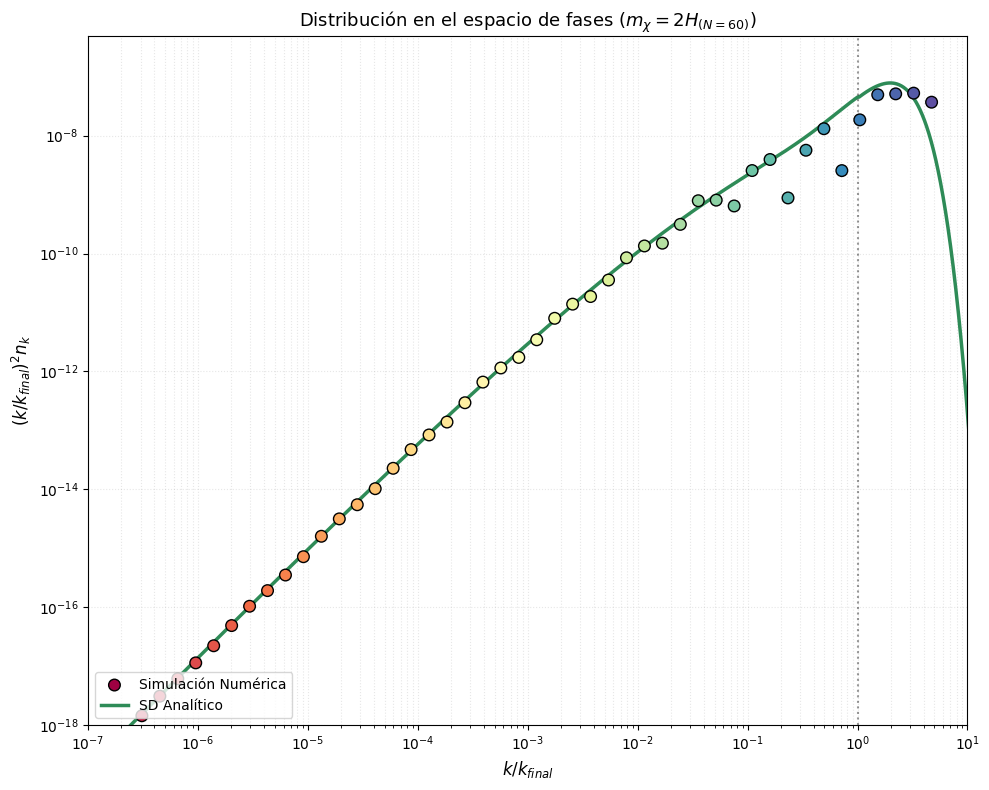

In [46]:

# ============================================================
# 5. PLOT
# ============================================================
colores_spec = cm.Spectral(np.linspace(0, 1, len(nk_final_lista)))
fig, ax = plt.subplots(figsize=(10, 8))

if len(k_lista) > 0:
    #filtramos nans para el scatter
    mask_num = ~np.isnan(nk_final_lista)
    y_num_lin = (k_lista[mask_num]/k_final_infl)**2 * np.array(nk_final_lista)[mask_num]
    ax.scatter(k_lista[mask_num]/k_final_infl, y_num_lin, 
                  c=cm.Spectral(np.linspace(0, 1, len(y_num_lin))), 
                  edgecolor='black', s=70, zorder=5, label='Simulación Numérica')

#curva teórica sd
y_teoria_lin = k_ratios_analitico**2 * nk_total_teoria
ax.loglog(k_ratios_analitico, y_teoria_lin, color='seagreen', ls='-', lw=2.5, label=r'SD Analítico')

#ajustes estéticos idénticos a los originales
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(1.0, color='black', ls=':', alpha=0.4)
ax.set_xlabel(r'$k/k_{final}$', fontsize=12)
ax.set_ylabel(r'$(k/k_{final})^2 n_k$', fontsize=12)
ax.set_ylim(1e-18, 5e-7)
ax.set_xlim(1e-7, 10)
ax.set_title(r'Distribución en el espacio de fases ($m_\chi = 2 H_{(N=60)}$)', fontsize=13)
ax.grid(True, which="both", ls=':', alpha=0.3)
ax.legend(fontsize=10, loc='lower left', frameon=True)

plt.tight_layout()

# ============================================================
# 6. VALOR DE LA INTEGRAL EN EL ESPACIO DE FASES
# ============================================================
integral_fases = np.trapezoid(y_teoria_lin, x=k_ratios_analitico)
n_total_normalizada = (1.0 / (2 * np.pi**2)) * integral_fases

print(f"\n--- RESULTADO DE LA PRODUCCIÓN TOTAL ---")
print(f"n_chi / k_final^3 = {n_total_normalizada:.6e} m_chi/H_(N=60)")
bbox_ax = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# Nombre dinámico que incluye tanto alpha como m_chi
nombre_archivo = f"Fig8_Espacio_Fases_Starobinsky_alpha{alpha}_mchi{m_chi}.pdf"
plt.savefig(nombre_archivo, bbox_inches=bbox_ax)

print(f"Gráfico exportado correctamente como: '{nombre_archivo}'")
plt.show()

## $Ajuste \,Densidad \,Comóvil$

 Masa | Producción Total (n/k_final^3)
---------------------------------------------
  2.0 |              9.692016e-04
  3.0 |              3.879754e-05
  4.0 |              1.609105e-06
  5.0 |              6.532586e-08
  6.0 |              2.589541e-09

--- RESULTADOS DEL AJUSTE ---
Parámetro A: 29.5370
Parámetro B: 0.4877
Gráfico exportado correctamente como: 'Fig9_Barrido_Masas_Starobinsky_alpha1.0.pdf'


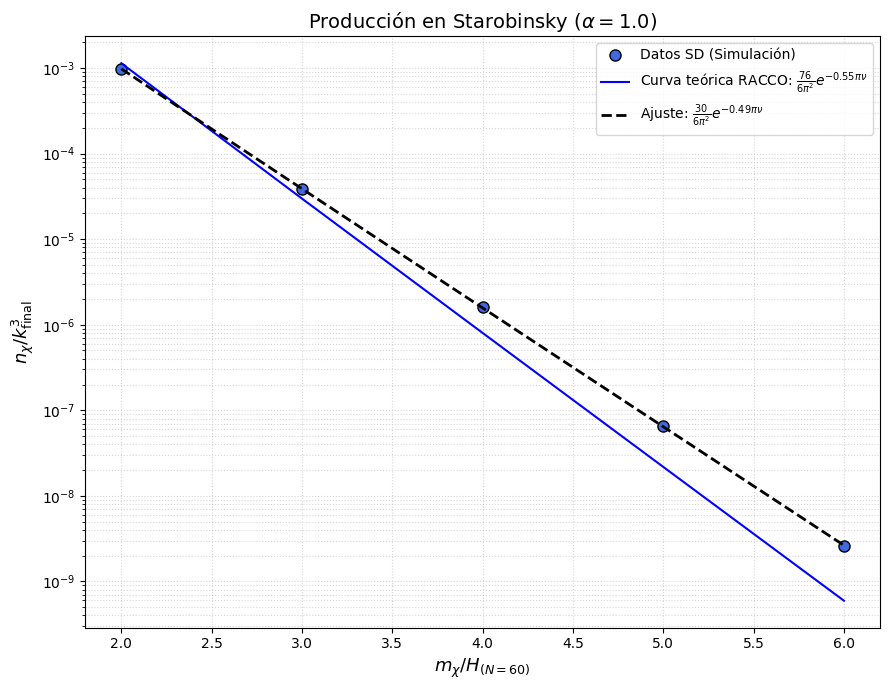

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root, brentq, minimize, curve_fit
from scipy.integrate import solve_ivp, trapezoid
from scipy.interpolate import interp1d
import cmath

# ============================================================
# 1. PARÁMETROS DEL MODELO Y CONFIGURACIÓN (HI=1)
# ============================================================
M_planck, H_inflacion = 1.0, 1.0 
alpha = 1.0          
N_objetivo = 60.0    
lambda_pot = 4.0 * H_inflacion**2
b_pot = np.sqrt(2 / (3 * alpha))
m_phi = 2 * H_inflacion / np.sqrt(alpha) 

tol_rel, tol_abs = 1e-11, 1e-13


# ============================================================
# 2. DINÁMICA DE FONDO Y CALIBRACIÓN
# ============================================================
def potencial_V(phi): 
    return 0.75 * lambda_pot * (1 - np.exp(-b_pot * phi))**2

def derivada_V(phi): 
    return 1.5 * b_pot * lambda_pot * (1 - np.exp(-b_pot * phi)) * np.exp(-b_pot * phi)

def ecuaciones_fondo(t, y):
    phi, phip, loga = y
    H = np.sqrt((0.5 * phip**2 + potencial_V(phi)) / 3.0)
    return [phip, -3 * H * phip - derivada_V(phi), H]

def cuenta_efolds(p0):
    #simulación para calibrar los e-folds generados
    sol_bg = solve_ivp(ecuaciones_fondo, (0, 1000), [p0, 0, 0], rtol=1e-8)
    H = np.sqrt((0.5 * sol_bg.y[1]**2 + potencial_V(sol_bg.y[0])) / 3.0)
    epsilon = (sol_bg.y[1]**2) / (2 * H**2)
    idx_final = np.where(epsilon >= 1.0)[0]
    return sol_bg.y[2][idx_final[0]] if len(idx_final) > 0 else 0

phi0_exacto = brentq(lambda p: cuenta_efolds(p) - N_objetivo, 5.0, 6.5)
sol_fnd = solve_ivp(ecuaciones_fondo, (0, 500), [phi0_exacto, 0, 0], 
                    t_eval=np.linspace(0, 500, 20000), rtol=tol_rel, atol=tol_abs)

t_f, a_f = sol_fnd.t, np.exp(sol_fnd.y[2])
H_f = np.sqrt((0.5 * sol_fnd.y[1]**2 + potencial_V(sol_fnd.y[0])) / 3.0)
Hd_f = - (sol_fnd.y[1]**2) / 2.0

idx_fin = np.argmax((sol_fnd.y[1]**2 / (2 * H_f**2)) > 1.0)
t_final, H_final, a_final, Hd_final = t_f[idx_fin], H_f[idx_fin], a_f[idx_fin], Hd_f[idx_fin]
k_final = a_final * H_final

#interpoladores para el cálculo de los modos analíticos
interp_a = interp1d(t_f, a_f, kind='cubic', fill_value="extrapolate")
interp_H = interp1d(t_f, H_f, kind='cubic', fill_value="extrapolate")
interp_Hd = interp1d(t_f, Hd_f, kind='cubic', fill_value="extrapolate")
interp_tc = interp1d(np.log(a_f * H_f), t_f, kind='linear', fill_value="extrapolate")

# ============================================================
# 3. IMPLEMENTACIÓN DEL SD (RAMAS HUBBLE Y RECALENTAMIENTO)
# ============================================================
def omega2_compleja(t_c, k_v, m_chi_val):
    tr, ti = t_c.real, t_c.imag
    hr, hdr = interp_H(tr), interp_Hd(tr)
    a2_c = (interp_a(tr)**2) * cmath.exp(2j * hr * ti)
    return k_v**2 / a2_c + m_chi_val**2 - 2.25 * hr**2 - 1.5 * hdr


def rama_hubble_analitica(ki, m_chi_val, polo_previo):
    #semilla basada en el tiempo de cruce de horizonte
    try: t_s = min(float(interp_tc(np.log(ki))), t_final - 0.1)
    except: t_s = t_final - 5.0
    
    res = minimize(lambda x: np.abs(omega2_compleja(x[0] + 1j * x[1], ki, m_chi_val))**2, 
                    [t_s, 1.95 if polo_previo is None else polo_previo.imag], 
                    method='Nelder-Mead', tol=1e-15)
    tp = res.x[0] + 1j * res.x[1]
    
    if res.fun < 1e-11 and tp.real < t_final + 2.0:
        ys = np.linspace(0, abs(tp.imag), 3000)
        ws = [cmath.sqrt(omega2_compleja(tp.real + 1j * y, ki, m_chi_val)) for y in ys]
        for j in range(1, len(ws)):
            if np.real(ws[j] * np.conj(ws[j-1])) < 0: ws[j] = -ws[j]
        integral = trapezoid(ws, x=ys)
        return (np.pi**2 / 9.0) * np.exp(-4.0 * np.abs(integral.real)), tp
    return np.nan, polo_previo


def rama_recalentamiento_analitica(ki, m_chi_val, z0):
    #potencial oscilatorio tras el fin de la inflación
    w2_recal = lambda t_c: (ki**2 / a_final**2) + m_chi_val**2 - (1.125 * H_final**2 * cmath.cos(2.0 * m_phi * t_c))
    #el polo tp se calcula con la masa local m_chi_val para el bucle
    tp = 1j * (1.0 / (2.0 * m_phi)) * np.log((8.0/9.0) * (m_chi_val**2 / H_final**2))
    ys = np.linspace(0, abs(tp.imag), 2000)
    ws = np.array([cmath.sqrt(w2_recal(tp.real + 1j*y)) for y in ys])
    integral = trapezoid(ws.real, x=ys)
    return (np.pi**2 / 9.0) * np.exp(-4.0 * integral), tp

# ============================================================
# 4. BARRIDO DE MASAS Y PRODUCCIÓN TOTAL
# ============================================================
masas_lista = np.arange(2.0, 7.0, 1.0)
res_n_total = []
res_teoria_fija = []
k_ir = np.logspace(-7, 0.000001, 100)   # Zona de salida de horizonte
k_uv = np.linspace(0.01, 15.0, 500)   # Zona de recalentamiento (malla densa)
k_ratios = np.sort(np.unique(np.concatenate([k_ir, k_uv])))

print(f"{'Masa':>5} | {'Producción Total (n/k_final^3)':>25}")
print("-" * 45)

for m in masas_lista:
    nk_hubble_raw, nk_preheat_raw = [], []
    polo_h, polo_p = None, [0.0, 1.5]
    
    for kr in k_ratios:
        ki = kr * k_final
        #1. rama hubble (transición)
        val_h, polo_h = rama_hubble_analitica(ki, m, polo_h)
        nk_hubble_raw.append(val_h)
        #2. rama recalentamiento (9/8)
        val_p, tp_p_comp = rama_recalentamiento_analitica(ki, m, [0.0, polo_p[1]])
        polo_p = [tp_p_comp.real, tp_p_comp.imag]
        nk_preheat_raw.append(val_p)
    
    #procesado de la continuidad de las ramas
    nk_h_arr = np.array(nk_hubble_raw)
    mask_h = (~np.isnan(nk_h_arr)) & (nk_h_arr > 1e-35)
    
    if np.any(mask_h):
        interp_h = interp1d(np.log10(k_ratios[mask_h]), np.log10(nk_h_arr[mask_h]), 
                            kind='linear', fill_value="extrapolate")
        hubble_f = 10**interp_h(np.log10(k_ratios))
        hubble_f[k_ratios > k_ratios[mask_h][-1] * 1.2] = np.nan
    else:
        hubble_f = np.zeros_like(k_ratios)
        
    nk_total_curva = np.nan_to_num(hubble_f) + np.array(nk_preheat_raw)
    
    #integral en el espacio de fases
    y_integrar = k_ratios**2 * nk_total_curva
    n_normalizada = (1.0 / (2 * np.pi**2)) * trapezoid(y_integrar, x=k_ratios)
    
    #curva teórica de referencia fija
    nu_final_val = np.sqrt(max(0, (m / H_final)**2 - 2.25 - 1.5 * (Hd_final / H_final**2)))
    n_teor_fijo = (76.0 / (6.0 * np.pi**2)) * np.exp(-0.55 * np.pi * nu_final_val)
    
    res_n_total.append(n_normalizada)
    res_teoria_fija.append(n_teor_fijo)
    print(f"{m:5.1f} | {n_normalizada:25.6e}")

# ============================================================
# 5. AJUSTE DE PARÁMETROS POR MÍNIMOS CUADRADOS
# ============================================================
lista_nu = np.sqrt(np.maximum(0, (masas_lista/H_final)**2 - 2.25 - 1.5*Hd_final/(H_final)**2))

def modelo_log(nu, A, B):
    #ajuste logarítmico para mayor precisión en escalas pequeñas
    return np.log(A / (6.0 * np.pi**2)) - B * np.pi * nu

popt, pcov = curve_fit(modelo_log, lista_nu, np.log(res_n_total), p0=[76.0, 0.55])
A_best, B_best = popt

print(f"\n--- RESULTADOS DEL AJUSTE ---")
print(f"Parámetro A: {A_best:.4f}")
print(f"Parámetro B: {B_best:.4f}")

# ============================================================
# 6. REPRESENTACIÓN GRÁFICA COMPARATIVA
# ============================================================
plt.figure(figsize=(9, 7))
fig = plt.gcf()  
ax = plt.gca()
#1. datos de la simulación 
plt.semilogy(masas_lista, res_n_total, color='royalblue', marker='o', ls='', 
             markersize=8, markeredgecolor='black', label='Datos SD (Simulación)')

#2. curva teórica de referencia 
plt.semilogy(masas_lista, res_teoria_fija, color='blue', lw=1.5, label=fr'Curva teórica RACCO: $\frac{{76}}{{6\pi^2}} e^{{-0.55\pi\nu}}$')

#3. curva del ajuste dinámico 
m_fino = np.linspace(masas_lista[0], masas_lista[-1], 100)
nu_fino = np.sqrt(np.maximum(0, (m_fino/H_final)**2 - 2.25 - 1.5*Hd_final/(H_final)**2))
n_ajuste = (A_best / (6.0 * np.pi**2)) * np.exp(-B_best * np.pi * nu_fino)

plt.semilogy(m_fino, n_ajuste, 'k--', lw=2, label=fr'Ajuste: $\frac{{{A_best:.0f}}}{{6\pi^2}} e^{{{-B_best:.2f}\pi\nu}}$')

plt.xlabel(r"$m_\chi / H_{(N=60)}$", fontsize=13)
plt.ylabel(r"$n_{\chi} / k_{\rm final}^3$", fontsize=13)
plt.title(r"Producción en Starobinsky $(\alpha=1.0)$", fontsize=14)
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()
bbox_ax = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# Guardar de forma independiente el gráfico perfectamente recortado
nombre_archivo = f"Fig9_Barrido_Masas_Starobinsky_alpha{alpha}.pdf"
plt.savefig(nombre_archivo, bbox_inches=bbox_ax)

print(f"Gráfico exportado correctamente como: '{nombre_archivo}'")
plt.show()

Figuras guardadas: 'Fig10_Escala_Inflacion_Materia_Oscura_alpha1.0.pdf' y 'Fig11_Temperatura_Recalentamiento_Materia_Oscura_alpha1.0.pdf'


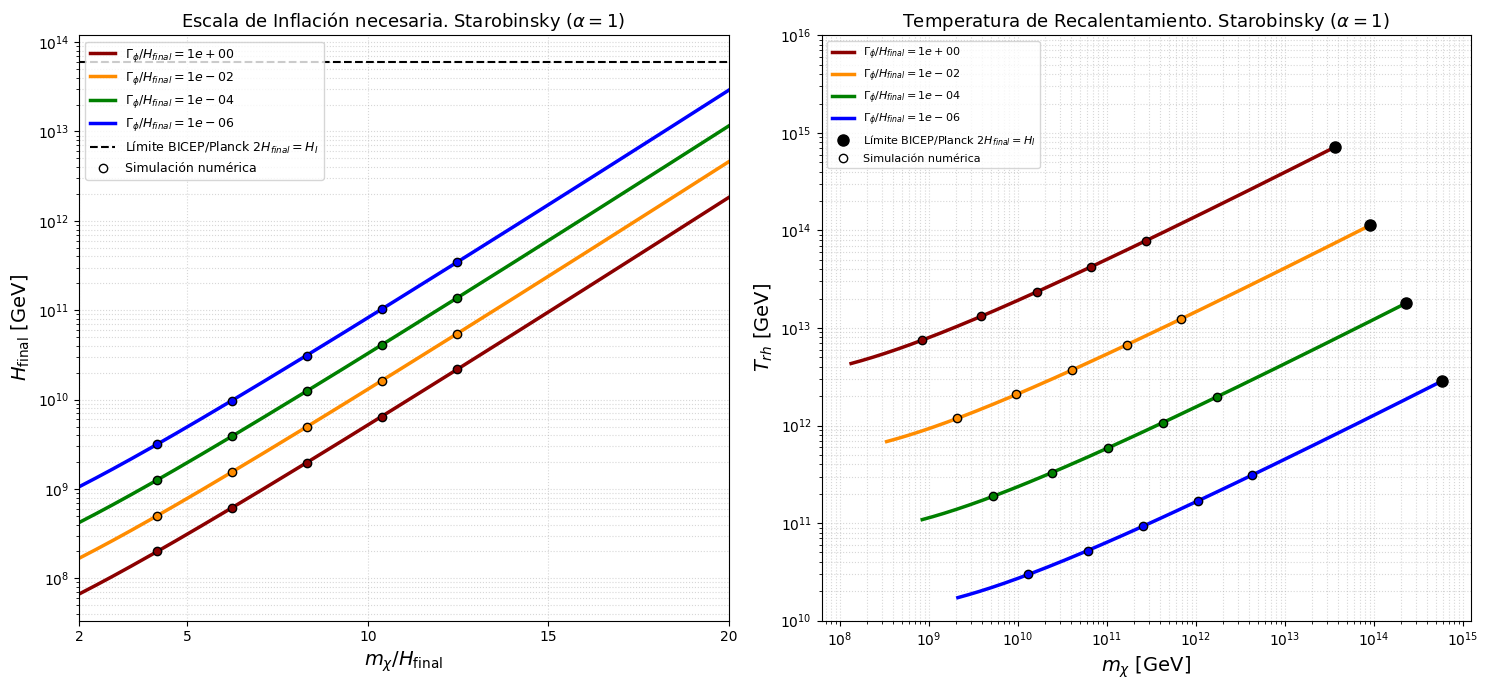

In [36]:
# ============================================================
# 7. ESPACIO DE PARÁMETROS DE MATERIA OSCURA (STAROBINSKY)
# ============================================================
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D

M_pl   = 2.435e18
g_star = 106.75
h_limite_cmb = 6e13  # Límite experimental para H_I en GeV

def H_end_from_abundance(n_bar, mu, r_gamma):
    # Normalización de grados de libertad para Starobinsky
    g_factor = (g_star / 106.75)**(-0.25)
    
    # Despeje de H_end desde la abundancia observada
    term_n = n_bar / 6e-10
    term_gamma = np.sqrt(r_gamma / 1e-3)
    brackets = (0.12 * g_factor) / (term_n * mu * term_gamma)
    return 1e12 * np.power(brackets, 0.4)

def T_rh_from_H_end(H_end_val, r_gamma):
    Gamma = r_gamma * H_end_val
    return 1.7e15 * g_star**(-0.25) * np.sqrt(Gamma / 1e12)

ratios_gamma_h = [1, 1e-2, 1e-4, 1e-6]
colores_dm = ['darkred', 'darkorange', 'green', 'blue']

# Corrección de mayúsculas según variables de scripts previos
ratios_reales_puntos = masas_lista / H_final
n_puntos = np.array(res_n_total)

masas_ratio_ext = np.linspace(2.0, 20.0, 500)
nu_ext = np.sqrt(np.maximum(0, masas_ratio_ext**2 - 2.25 - 1.5 * Hd_final / (H_final)**2))
n_comovil_fit = (A_best / (6.0 * np.pi**2)) * np.exp(-B_best * np.pi * nu_ext)

fig_dm, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

for r_gamma, color in zip(ratios_gamma_h, colores_dm):
    etiqueta = rf'$\Gamma_\phi/H_{{final}} = {r_gamma:.0e}$'

    # --- 1. Cálculos de las curvas continuas (Fit) ---
    h_fit   = H_end_from_abundance(n_comovil_fit, masas_ratio_ext, r_gamma)
    trh_fit = T_rh_from_H_end(h_fit, r_gamma)
    m_chi_gev_fit = masas_ratio_ext * h_fit

    ax1.semilogy(masas_ratio_ext, h_fit, color=color, lw=2.5, label=etiqueta)
    
    # Máscara para detener el gráfico de la derecha si supera el límite
    mascara_v = h_fit <= h_limite_cmb
    ax2.loglog(m_chi_gev_fit[mascara_v], trh_fit[mascara_v], color=color, lw=2.5, label=etiqueta)

    # --- 2. Cálculos de los puntos discretos (Simulación) ---
    h_p   = H_end_from_abundance(n_puntos, ratios_reales_puntos, r_gamma)
    trh_p = T_rh_from_H_end(h_p, r_gamma)
    m_chi_p = ratios_reales_puntos * h_p

    ax1.plot(ratios_reales_puntos, h_p, marker='o', ls='', color=color,
             markersize=6, markeredgecolor='black', zorder=5)
    
    # Filtro también los puntos numéricos para el panel derecho
    mascara_p = h_p <= h_limite_cmb
    ax2.plot(m_chi_p[mascara_p], trh_p[mascara_p], marker='o', ls='', color=color,
             markersize=6, markeredgecolor='black', zorder=5)

    # Marcador negro para señalar el punto exacto de corte con BICEP
    if np.any(mascara_v):
        idx_corte = np.argmin(np.abs(h_fit - h_limite_cmb))
        ax2.plot(m_chi_gev_fit[idx_corte], trh_fit[idx_corte], marker='o', color='black',
                 markersize=8, zorder=6)

# Configuración formal del panel izquierdo
ax1.axhline(h_limite_cmb, color='black', ls='--', lw=1.5, label=r'Límite BICEP/Planck $2H_{final}=H_I$')
ax1.set_xscale('linear')
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.set_xticks([2, 5, 10, 15, 20])
ax1.set_xlim(2, 20)
ax1.set_xlabel(r'$m_\chi / H_{\rm final}$', fontsize=14)
ax1.set_ylabel(r'$H_{\rm final}\ {\rm [GeV]}$', fontsize=14)
ax1.set_title(r'Escala de Inflación necesaria. Starobinsky $(\alpha=1)$ ', fontsize=13)
ax1.grid(True, which='both', ls=':', alpha=0.5)

# Leyenda para el panel izquierdo (Curvas + Indicador de puntos)
manejadores1, etiquetas1 = ax1.get_legend_handles_labels()
extra_ax1 = [Line2D([0],[0], marker='o', color='w', ls='', ms=6, mec='k', label='Simulación numérica')]
ax1.legend(handles=manejadores1 + extra_ax1, fontsize=9, frameon=True, loc='upper left')

# Configuración formal del panel derecho
ax2.set_ylim(1e10, 1e16)
ax2.set_xlabel(r'$m_\chi\ [\mathrm{GeV}]$', fontsize=14)
ax2.set_ylabel(r'$T_{rh}\ {\rm [GeV]}$', fontsize=14)
ax2.set_title(r'Temperatura de Recalentamiento. Starobinsky $(\alpha=1)$', fontsize=13)
ax2.grid(True, which='both', ls=':', alpha=0.5)

# Leyenda unificada y limpia para el panel derecho
manejadores2, etiquetas2 = ax2.get_legend_handles_labels()
leyenda_extra = [
    Line2D([0],[0], marker='o', color='black', ls='', ms=8, label=r'Límite BICEP/Planck $2H_{final}=H_I$'),
    Line2D([0],[0], marker='o', color='w', ls='', ms=6, mec='k', label='Simulación numérica')
]
etiquetas_completas = etiquetas2[:4] + [h.get_label() for h in leyenda_extra]
ax2.legend(handles=manejadores2[:4] + leyenda_extra, labels=etiquetas_completas, fontsize=8, frameon=True, loc='upper left')

plt.tight_layout()

# ============================================================
# CÁLCULO DE COORDENADAS Y GUARDADO SEPARADO (BBOX TRICK)
# ============================================================
bbox_ax1 = ax1.get_tightbbox(fig_dm.canvas.get_renderer()).transformed(fig_dm.dpi_scale_trans.inverted()).expanded(1.05, 1.05)
bbox_ax2 = ax2.get_tightbbox(fig_dm.canvas.get_renderer()).transformed(fig_dm.dpi_scale_trans.inverted()).expanded(1.05, 1.05)

# Guardar los PDFs individuales de manera independiente
plt.savefig(f"Fig10_Escala_Inflacion_Materia_Oscura_alpha{alpha}.pdf", bbox_inches=bbox_ax1)
plt.savefig(f"Fig11_Temperatura_Recalentamiento_Materia_Oscura_alpha{alpha}.pdf", bbox_inches=bbox_ax2)

print(f"Figuras guardadas: 'Fig10_Escala_Inflacion_Materia_Oscura_alpha{alpha}.pdf' y 'Fig11_Temperatura_Recalentamiento_Materia_Oscura_alpha{alpha}.pdf'")
plt.show()

# DECLARACIÓN RESPONSABLE DEL USO DE IA

Para la realización de los códigos presentes en este documento se han utilizado herramientas de Inteligencia Artificial para mejorar la eficiencia y aspecto del código